### imports

In [14]:
# pyright: reportArgumentType=false, reportOptionalMemberAccess=false, reportAttributeAccessIssue=false, reportWildcardImportFromLibrary=false, reportInvalidStringEscapeSequence=false
import sys
sys.path.insert(0, "..")
import tensorflow as tf
keras = tf.keras
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Any

def as_float(v: Any, default: float = np.nan) -> float:
    if v is None:
        return float(default)
    try:
        return float(v)
    except Exception:
        try:
            return float(np.asarray(v).reshape(-1)[0])
        except Exception:
            return float(default)

def as_int(v: Any, default: int = 0) -> int:
    if v is None:
        return int(default)
    try:
        return int(v)
    except Exception:
        try:
            return int(np.asarray(v).reshape(-1)[0])
        except Exception:
            return int(default)

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / "data").exists():
    DATAPATH = REPO_ROOT / "data"
elif (REPO_ROOT.parent / "data").exists():
    DATAPATH = REPO_ROOT.parent / "data"
else:
    DATAPATH = Path(r"D:\Dev\ParamEst-NN\ParamEst-NN-main\data")
if not DATAPATH.exists():
    raise FileNotFoundError(f"DATAPATH does not exist: {DATAPATH}")
from tqdm import tqdm

my_seed_number = 42
# Set the random seed for TensorFlow
tf.random.set_seed(my_seed_number)

# Set the random seed for NumPy (used by TensorFlow for certain operations)
np.random.seed(my_seed_number)

### 2D RFF+laplace Model

#### 加载数据

In [15]:
path_tau= DATAPATH/"training-trajectories/2D-delta-omega/taus2D.npy"
path_param= DATAPATH/"training-trajectories/2D-delta-omega/param_rand_list-2D.npy"
L_max = 48
L_choices = tf.constant([10, 15, 20, 30, 40, 48], dtype=tf.int32)
tau_list = np.load(path_tau)[:, :L_max]
param_list = np.load(path_param)

target_ntraj = 100000
ntraj_select = min(target_ntraj, tau_list.shape[0])
tau_list = tau_list[:ntraj_select].astype(np.float32)
param_list = param_list[:ntraj_select].astype(np.float32)

njumps = tau_list.shape[1]

# Set data generated from Monte Carlo
x_train_full, y_train_full = tau_list, param_list

lenTrain=int(0.8*len(x_train_full))
x_train, x_valid = x_train_full[:lenTrain], x_train_full[lenTrain:]
y_train, y_valid = y_train_full[:lenTrain], y_train_full[lenTrain:]

# ---- Adaptive lambda range for exponential branch ----
# Match Laplace basis scale to observed inter-event times
taus_pos = tau_list[tau_list > 0.0]
q10_tau = float(np.quantile(taus_pos, 0.10))
q90_tau = float(np.quantile(taus_pos, 0.90))

# Keep lambda*tau in an informative range roughly [0.2, 5]
lam_min_auto = max(1e-4, 0.2 / max(q90_tau, 1e-6))
lam_max_auto = min(1e2, 5.0 / max(q10_tau, 1e-6))
if lam_max_auto <= lam_min_auto:
    lam_max_auto = lam_min_auto * 10.0


#### 定义 RFF layer + laplace layer

In [16]:
@keras.saving.register_keras_serializable()
class RFFFeatures(keras.layers.Layer):
    def __init__(self, K=32, w_max=20.0, seed=0, eps=1e-6, use_log=True, **kwargs):
        super().__init__(trainable=False, **kwargs)
        self.K = int(K)
        self.w_max = float(w_max)
        self.seed = int(seed)
        self.eps = float(eps)
        self.use_log = bool(use_log)

    def build(self, input_shape):
        rng = np.random.default_rng(self.seed)
        xi = rng.uniform(-self.w_max, self.w_max, size=(self.K,)).astype(np.float32)
        self.xi = self.add_weight(
            name="xi",
            shape=(self.K,),
            initializer=tf.constant_initializer(xi),
            trainable=False,
        )

    def call(self, taus):
        # taus: (B, T) padded with 0
        mask = tf.cast(taus > 0.0, tf.float32)
        denom = tf.reduce_sum(mask, axis=1, keepdims=True) + 1e-6

        x = taus
        if self.use_log:
            x = tf.math.log(x + self.eps)

        phase = tf.expand_dims(x, axis=-1) * self.xi
        c = tf.math.cos(phase) * tf.expand_dims(mask, -1)
        s = tf.math.sin(phase) * tf.expand_dims(mask, -1)

        c_mean = tf.reduce_sum(c, axis=1) / denom
        s_mean = tf.reduce_sum(s, axis=1) / denom

        return tf.concat([c_mean, s_mean], axis=-1)

    def get_config(self):
        return {
            "K": self.K,
            "w_max": self.w_max,
            "seed": self.seed,
            "eps": self.eps,
            "use_log": self.use_log,
        }


@keras.saving.register_keras_serializable()
class ExpLaplaceFeatures(keras.layers.Layer):
    """
    Exponential-sensitive features for decaying statistics:
      f_k = mean(exp(-lambda_k * tau))
      g_k = mean(tau * exp(-lambda_k * tau))
    over valid events tau>0.
    """

    def __init__(self, K=64, lam_min=1e-2, lam_max=1e1, seed=0, **kwargs):
        super().__init__(trainable=False, **kwargs)
        self.K = int(K)
        self.lam_min = float(lam_min)
        self.lam_max = float(lam_max)
        self.seed = int(seed)

    def build(self, input_shape):
        rng = np.random.default_rng(self.seed)
        # log-uniform lambda sampling improves multi-scale decay sensitivity
        log_lam = rng.uniform(np.log(self.lam_min), np.log(self.lam_max), size=(self.K,)).astype(np.float32)
        lam = np.exp(log_lam).astype(np.float32)
        self.lam = self.add_weight(
            name="lam",
            shape=(self.K,),
            initializer=tf.constant_initializer(lam),
            trainable=False,
        )

    def call(self, taus):
        # taus: (B, T), padded with 0
        mask = tf.cast(taus > 0.0, tf.float32)
        denom = tf.reduce_sum(mask, axis=1, keepdims=True) + 1e-6

        t = tf.cast(taus, tf.float32)
        exp_term = tf.exp(-tf.expand_dims(t, -1) * self.lam)
        exp_term = exp_term * tf.expand_dims(mask, -1)

        f = tf.reduce_sum(exp_term, axis=1) / denom
        g = tf.reduce_sum(exp_term * tf.expand_dims(t, -1), axis=1) / denom

        return tf.concat([f, g], axis=-1)

    def get_config(self):
        return {
            "K": self.K,
            "lam_min": self.lam_min,
            "lam_max": self.lam_max,
            "seed": self.seed,
        }



#### 参数网格

In [17]:
# 选参数网格
delta_min, delta_max, K1 = 0, 3, 50      # Δ
omega_min, omega_max, K2 = 0.25, 5, 50       # ω

p1_grid = np.linspace(delta_min, delta_max, K1).astype(np.float32)
p2_grid = np.linspace(omega_min, omega_max, K2).astype(np.float32)

p1_tf = tf.constant(p1_grid, dtype=tf.float32)  # (K1,)
p2_tf = tf.constant(p2_grid, dtype=tf.float32)  # (K2,)

def to_grid_index_1d(y, ymin, ymax, K):
    idx = np.rint((y - ymin) / (ymax - ymin) * (K - 1)).astype(np.int32)
    return np.clip(idx, 0, K - 1)

def make_joint_labels_from_param(param, delta_min, delta_max, K1, omega_min, omega_max, K2):
    delta = param[:, 0]
    omega = param[:, 1]
    idx_delta = to_grid_index_1d(delta, delta_min, delta_max, K1)
    idx_omega = to_grid_index_1d(omega, omega_min, omega_max, K2)
    joint = (idx_delta * K2 + idx_omega).astype(np.int32)
    return joint, idx_delta, idx_omega

joint_train, _, _ = make_joint_labels_from_param(
    y_train, delta_min, delta_max, K1, omega_min, omega_max, K2
)
joint_valid, _, _ = make_joint_labels_from_param(
    y_valid, delta_min, delta_max, K1, omega_min, omega_max, K2
)

joint_train = joint_train.astype(np.int32)
joint_valid = joint_valid.astype(np.int32)

L_max_tf = tf.constant(L_max, dtype=tf.int32)

def crop_and_joint(tau, joint):
    L = tf.random.shuffle(L_choices)[0]
    tau_crop = tau[:L]          # 只取前面的
    return tau_crop, joint

batch_size = 2048

train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, joint_train))
    .shuffle(20000)
    .map(crop_and_joint, num_parallel_calls=tf.data.AUTOTUNE)
    .padded_batch(
        batch_size,
        padded_shapes=(tf.TensorShape([None]), tf.TensorShape([])),
        padding_values=(tf.constant(0.0, tf.float32), tf.constant(0, tf.int32))
    )
    .prefetch(tf.data.AUTOTUNE)
)

valid_ds = (
    tf.data.Dataset.from_tensor_slices((x_valid, joint_valid))
    .padded_batch(
        batch_size,
        padded_shapes=(tf.TensorShape([None]), tf.TensorShape([])),
        padding_values=(tf.constant(0.0, tf.float32), tf.constant(0, tf.int32))
    )
    .prefetch(tf.data.AUTOTUNE)
)


#### 定义模型

In [18]:
def create_model_RFF2D(
    K1=80, K2=80,
    Kfeat=128, w_max=5, seed=0,
    use_log=True,
    add_logN=True,
    # exponential branch
    add_exp=True,
    Kexp=64,
    lam_min=1e-2,
    lam_max=1e1,
    # DeepSets event branch
    add_deepset=True,
    ds_width=128,
    ds_depth=3,
    activation="relu",
    droprate=0.0,
):
    inp = keras.Input(shape=(None,), name="taus")  # (B, L)

    # RFF features: (B, 2*Kfeat)
    rff = RFFFeatures(K=Kfeat, w_max=w_max, seed=seed, use_log=use_log, name="rff")(inp)
    feat_list = [rff]

    # Exponential-sensitive branch (delta-related decay information)
    if add_exp:
        exp_feat = ExpLaplaceFeatures(
            K=Kexp,
            lam_min=lam_min,
            lam_max=lam_max,
            seed=seed + 1,
            name="exp_laplace",
        )(inp)
        feat_list.append(exp_feat)

    # DeepSets branch: trainable event encoder + masked mean pooling
    if add_deepset:
        mask = keras.layers.Lambda(lambda t: tf.cast(t > 0.0, tf.float32), name="ds_mask")(inp)
        tlog = keras.layers.Lambda(lambda t: tf.math.log(t + 1e-6), name="ds_logtau")(inp)

        evt_raw = keras.layers.Lambda(lambda t: tf.expand_dims(t, -1), name="ds_expand_raw")(inp)
        evt_log = keras.layers.Lambda(lambda t: tf.expand_dims(t, -1), name="ds_expand_log")(tlog)
        evt = keras.layers.Concatenate(name="ds_evt_concat")([evt_raw, evt_log])

        h = evt
        for k in range(ds_depth):
            h = keras.layers.TimeDistributed(
                keras.layers.Dense(ds_width, activation=activation),
                name=f"ds_td_{k+1}"
            )(h)

        mask_e = keras.layers.Lambda(lambda m: tf.expand_dims(m, -1), name="ds_mask_expand")(mask)
        h_masked = keras.layers.Multiply(name="ds_masked")([h, mask_e])
        h_sum = keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), name="ds_sum")(h_masked)
        denom = keras.layers.Lambda(
            lambda m: tf.reduce_sum(m, axis=1, keepdims=True) + 1e-6,
            name="ds_denom"
        )(mask)
        ds_feat = keras.layers.Lambda(lambda x: x[0] / x[1], name="ds_mean")([h_sum, denom])
        ds_feat = keras.layers.Dense(ds_width, activation=activation, name="ds_post_dense")(ds_feat)
        feat_list.append(ds_feat)

    # Optional: logN feature for mixed lengths
    if add_logN:
        logN = keras.layers.Lambda(
            lambda t: tf.math.log(tf.reduce_sum(tf.cast(t > 0.0, tf.float32), axis=1, keepdims=True) + 1e-6),
            name="logN"
        )(inp)
        feat_list.append(logN)

    feats = keras.layers.Concatenate(name="concat_feat")(feat_list) if len(feat_list) > 1 else feat_list[0]

    # MLP head
    x = keras.layers.Dense(100, activation=activation)(feats)
    x = keras.layers.Dropout(droprate)(x)
    x = keras.layers.Dense(50, activation=activation)(x)
    x = keras.layers.Dropout(droprate)(x)
    x = keras.layers.Dense(30, activation=activation)(x)
    x = keras.layers.Dropout(droprate)(x)
    x = keras.layers.Dense(20, activation=activation)(x)
    x = keras.layers.Dropout(droprate)(x)
    x = keras.layers.Dense(10, activation=activation)(x)
    x = keras.layers.Dropout(droprate)(x)

    logits = keras.layers.Dense(K1 * K2, name="joint_logits")(x)
    return keras.Model(inp, logits, name="RFF_2Dposterior")


modelRFF2D = create_model_RFF2D(
    K1=K1, K2=K2,
    Kfeat=512,
    w_max=5,
    seed=0,
    use_log=True,
    add_logN=True,
    add_exp=True,
    Kexp=128,
    lam_min=lam_min_auto,
    lam_max=lam_max_auto,
    add_deepset=True,
    ds_width=128,
    ds_depth=3,
    droprate=0.0
)


#### 训练

In [19]:
# Reuse saved model by default. Set True only when you want to retrain.
FORCE_RETRAIN = False

model_dir_2d = DATAPATH / "models" / "2D"
model_dir_2d.mkdir(parents=True, exist_ok=True)
model_path = model_dir_2d / "rff2d_latest.keras"
weights_path = model_dir_2d / "rff2d_latest.weights.h5"


def load_rff2d_model_or_weights(model_path, weights_path):
    if model_path.exists():
        try:
            model = keras.models.load_model(model_path, safe_mode=False, compile=False)
            print(f"Loaded .keras model: {model_path}")
            return model
        except TypeError:
            # Compatibility path for environments without safe_mode argument.
            if hasattr(keras, "config") and hasattr(keras.config, "enable_unsafe_deserialization"):
                keras.config.enable_unsafe_deserialization()
            try:
                model = keras.models.load_model(model_path, compile=False)
                print(f"Loaded .keras model (unsafe deserialization enabled): {model_path}")
                return model
            except Exception as e:
                print(f".keras load failed ({e}); fallback to weights loading.")
        except Exception as e:
            print(f".keras load failed ({e}); fallback to weights loading.")

    if not weights_path.exists():
        raise FileNotFoundError(
            f"Neither loadable .keras model nor weights file found. Checked: {model_path} and {weights_path}"
        )

    model = create_model_RFF2D(
        K1=K1, K2=K2,
        Kfeat=512,
        w_max=5,
        seed=0,
        use_log=True,
        add_logN=True,
        add_exp=True,
        Kexp=128,
        lam_min=lam_min_auto,
        lam_max=lam_max_auto,
        add_deepset=True,
        ds_width=128,
        ds_depth=3,
        droprate=0.0,
    )
    model.load_weights(weights_path)
    print(f"Loaded weights into rebuilt model: {weights_path}")
    return model


modelRFF2D = None
did_train = False

tf.keras.backend.clear_session()

if not FORCE_RETRAIN:
    try:
        modelRFF2D = load_rff2d_model_or_weights(model_path, weights_path)
    except Exception as e:
        print(f"Model reuse failed ({e}); will retrain.")

if modelRFF2D is None:
    modelRFF2D = create_model_RFF2D(
        K1=K1, K2=K2,
        Kfeat=512,
        w_max=5,
        seed=0,
        use_log=True,
        add_logN=True,
        add_exp=True,
        Kexp=128,
        lam_min=lam_min_auto,
        lam_max=lam_max_auto,
        add_deepset=True,
        ds_width=128,
        ds_depth=3,
        droprate=0.0
    )

    modelRFF2D.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    )
    modelRFF2D.fit(train_ds, validation_data=valid_ds, epochs=100)
    did_train = True
    print("Training finished.")


Epoch 1/100

40/40 [==============================] - 16s 368ms/step - loss: 7.7531 - val_loss: 7.5282
Epoch 2/100
40/40 [==============================] - 14s 358ms/step - loss: 7.3490 - val_loss: 7.0940
Epoch 3/100
40/40 [==============================] - 14s 360ms/step - loss: 7.0170 - val_loss: 6.7439
Epoch 4/100
40/40 [==============================] - 14s 360ms/step - loss: 6.8350 - val_loss: 6.6021
Epoch 5/100
40/40 [==============================] - 15s 377ms/step - loss: 6.7179 - val_loss: 6.4289
Epoch 6/100
40/40 [==============================] - 15s 365ms/step - loss: 6.6285 - val_loss: 6.3414
Epoch 7/100
40/40 [==============================] - 15s 363ms/step - loss: 6.5745 - val_loss: 6.2847
Epoch 8/100
40/40 [==============================] - 15s 363ms/step - loss: 6.5381 - val_loss: 6.2339
Epoch 9/100
40/40 [==============================] - 14s 357ms/step - loss: 6.5100 - val_loss: 6.2147
Epoch 10/100
40/40 [==============================] - 14s 357ms/step - loss: 6.49

#### 保存模型

In [20]:
if did_train:
    if modelRFF2D is None:
        raise RuntimeError("modelRFF2D is None after training; cannot save model.")
    modelRFF2D.save(model_path)
    modelRFF2D.save_weights(weights_path)
    print(f"Saved trained model to: {model_path}")
else:
    print(f"Using saved model without retraining: {model_path}")

saved_model_path = str(model_path)
saved_weights_path = str(weights_path)
saved_model_path, saved_weights_path


Saved trained model to: D:\Dev\ParamEst-NN\ParamEst-NN-main\data\models\2D\rff2d_latest.keras


('D:\\Dev\\ParamEst-NN\\ParamEst-NN-main\\data\\models\\2D\\rff2d_latest.keras',
 'D:\\Dev\\ParamEst-NN\\ParamEst-NN-main\\data\\models\\2D\\rff2d_latest.weights.h5')

#### 结果

In [23]:
def eval_for_L(model, x_valid, y_valid, p1_grid, p2_grid, L, cred_mass=0.68):
    logits = model.predict(x_valid[:, :L], verbose=0)
    probs = tf.nn.softmax(logits, axis=1).numpy()

    N = probs.shape[0]
    K1, K2 = len(p1_grid), len(p2_grid)
    probs_2d = probs.reshape(N, K1, K2)

    eps = 1e-12
    entropy = -np.sum(probs * np.log(probs + eps), axis=1)
    Hmax = np.log(K1 * K2)
    pmax = np.max(probs, axis=1)

    delta_hat = np.sum(probs_2d * p1_grid[:, None], axis=(1, 2))
    omega_hat = np.sum(probs_2d * p2_grid[None, :], axis=(1, 2))

    delta_true = y_valid[:, 0]
    omega_true = y_valid[:, 1]

    delta_rmse = np.sqrt(np.mean((delta_hat - delta_true) ** 2))
    omega_rmse = np.sqrt(np.mean((omega_hat - omega_true) ** 2))
    delta_mae = np.mean(np.abs(delta_hat - delta_true))
    omega_mae = np.mean(np.abs(omega_hat - omega_true))

    i_delta = np.argmin(np.abs(delta_true[:, None] - p1_grid[None, :]), axis=1)
    i_omega = np.argmin(np.abs(omega_true[:, None] - p2_grid[None, :]), axis=1)
    true_idx = (i_delta * K2 + i_omega).astype(np.int32)

    coverage = np.zeros(N, dtype=bool)
    for n in range(N):
        p = probs[n]
        order = np.argsort(p)[::-1]
        cum = np.cumsum(p[order])
        cutoff = np.searchsorted(cum, cred_mass)
        kept = order[:cutoff + 1]
        coverage[n] = np.any(kept == true_idx[n])

    return {
        "L": as_int(L),
        "pmax_mean": float(np.mean(pmax)),
        "entropy_mean": float(np.mean(entropy)),
        "entropy_ratio": float(np.mean(entropy) / Hmax),
        "delta_rmse": float(delta_rmse),
        "omega_rmse": float(omega_rmse),
        "delta_mae": float(delta_mae),
        "omega_mae": float(omega_mae),
        "coverage": float(np.mean(coverage)),
    }


### 2D CRB

#### 统一向量化 FIM

In [24]:
from paramest_nn.quantum_tools import compute_waiting_time


def logw(delta, omega, tau):
    tau_arr = np.asarray(tau, dtype=np.float64)
    if tau_arr.ndim == 0:
        w = compute_waiting_time(float(tau_arr), omega, delta)
        return np.log(w + 1e-300)
    w = np.array([compute_waiting_time(t, omega, delta) for t in tau_arr], dtype=np.float64)
    return np.log(w + 1e-300)


def _choose_step(x0, abs_min=1e-3, rel=5e-3, abs_max=None):
    h = max(float(abs_min), float(rel) * max(abs(float(x0)), 1.0))
    if abs_max is not None:
        h = min(h, float(abs_max))
    return h


def _fd_first_order(f, x0, h, lower=None, upper=None):
    if lower is not None and x0 - h < lower:
        return (f(x0 + h) - f(x0)) / h
    if upper is not None and x0 + h > upper:
        return (f(x0) - f(x0 - h)) / h
    return (f(x0 + h) - f(x0 - h)) / (2.0 * h)


def _fd_richardson(f, x0, h, lower=None, upper=None):
    d_h = _fd_first_order(f, x0, h, lower=lower, upper=upper)
    d_h2 = _fd_first_order(f, x0, 0.5 * h, lower=lower, upper=upper)
    return (4.0 * d_h2 - d_h) / 3.0


def _robust_fd(f, x0, h0, lower=None, upper=None, richardson=True):
    for scale in (1.0, 2.0, 4.0):
        h = h0 * scale
        if richardson:
            d = _fd_richardson(f, x0, h, lower=lower, upper=upper)
        else:
            d = _fd_first_order(f, x0, h, lower=lower, upper=upper)
        if np.all(np.isfinite(d)):
            return d
    return np.full_like(np.asarray(f(x0), dtype=np.float64), np.nan, dtype=np.float64)


def scores_events(
    delta,
    omega,
    tau,
    eps_d=1e-3,
    eps_o=1e-3,
    rel_step_d=5e-3,
    rel_step_o=5e-3,
    richardson=True,
    delta_lb=0.0,
    omega_lb=1e-8,
):
    tau = np.asarray(tau, dtype=np.float64)

    h_d = _choose_step(delta, abs_min=eps_d, rel=rel_step_d)
    h_o = _choose_step(omega, abs_min=eps_o, rel=rel_step_o)

    f_delta = lambda d: logw(d, omega, tau)
    f_omega = lambda o: logw(delta, o, tau)

    s_d = _robust_fd(f_delta, delta, h_d, lower=delta_lb, upper=None, richardson=richardson)
    s_o = _robust_fd(f_omega, omega, h_o, lower=omega_lb, upper=None, richardson=richardson)

    return np.stack([s_d, s_o], axis=-1)


def fisher_eventwise_one_traj(
    delta,
    omega,
    tau_list,
    eps_d=1e-3,
    eps_o=1e-3,
    rel_step_d=5e-3,
    rel_step_o=5e-3,
    richardson=True,
):
    tau = np.asarray(tau_list, dtype=np.float64)
    tau = tau[tau > 0.0]
    if tau.size == 0:
        return np.zeros((2, 2), dtype=np.float64)
    s = scores_events(
        delta,
        omega,
        tau,
        eps_d=eps_d,
        eps_o=eps_o,
        rel_step_d=rel_step_d,
        rel_step_o=rel_step_o,
        richardson=richardson,
    )
    return s.T @ s


#### PSD 投影 + 无偏/有偏 CRB

In [26]:
def project_to_psd(J, eig_floor=1e-8):
    J = 0.5 * (J + J.T)
    w, v = np.linalg.eigh(J)
    w = np.maximum(w, eig_floor)
    return (v * w) @ v.T


def crb_from_info_psd(J, eig_floor=1e-8):
    j_psd = project_to_psd(J, eig_floor=eig_floor)
    c = np.linalg.inv(j_psd)
    sigma = np.sqrt(np.diag(c))
    return c, sigma


def crb_biased(J, D, bias=None, eig_floor=1e-8):
    j_psd = project_to_psd(J, eig_floor=eig_floor)
    c_unb = np.linalg.inv(j_psd)
    d = np.asarray(D, dtype=np.float64)
    c_b = d @ c_unb @ d.T
    if bias is None:
        return c_b
    b = np.asarray(bias, dtype=np.float64).reshape(-1, 1)
    return c_b + b @ b.T

#### 数据集级别 CRB 包装

In [28]:
def crb_mix_over_L_for_dataset_eventwise(
    x, y, L_list, weights=None, eps_d=3e-3, eps_o=3e-3, eig_floor=1e-10, max_samples=None
):
    if weights is None:
        weights = np.ones(len(L_list), dtype=np.float64)
    w_norm = np.asarray(weights, dtype=np.float64)
    w_norm = w_norm / w_norm.sum()
    n = x.shape[0] if max_samples is None else min(x.shape[0], max_samples)
    sigmas_mix = np.full((n, 2), np.nan, dtype=np.float64)
    min_eigs = np.full(n, np.nan, dtype=np.float64)
    for idx in range(n):
        delta, omega = float(y[idx, 0]), float(y[idx, 1])
        i_mix = np.zeros((2, 2), dtype=np.float64)
        for w, l_val in zip(w_norm, L_list):
            tau = x[idx, :l_val]
            tau = tau[tau > 0.0]
            if tau.size == 0:
                continue
            i_mix = i_mix + w * fisher_eventwise_one_traj(
                delta, omega, tau, eps_d=eps_d, eps_o=eps_o
            )
        j_psd = project_to_psd(i_mix, eig_floor=eig_floor)
        vals = np.linalg.eigvalsh(j_psd)
        min_eigs[idx] = float(vals[0])
        c = np.linalg.inv(j_psd)
        sigmas_mix[idx] = np.sqrt(np.diag(c))
    valid = ~np.isnan(sigmas_mix).any(axis=1)
    vs = sigmas_mix[valid]
    ve = min_eigs[valid]
    out = {
        "L_list": list(L_list),
        "weights": w_norm.tolist(),
        "eps_d": float(eps_d),
        "eps_o": float(eps_o),
        "eig_floor": float(eig_floor),
        "N_used": int(vs.shape[0]),
        "N_bad": int(n - vs.shape[0]),
        "sigma_delta_mean": float(np.mean(vs[:, 0])),
        "sigma_delta_median": float(np.median(vs[:, 0])),
        "sigma_delta_p16": float(np.quantile(vs[:, 0], 0.16)),
        "sigma_delta_p84": float(np.quantile(vs[:, 0], 0.84)),
        "sigma_omega_mean": float(np.mean(vs[:, 1])),
        "sigma_omega_median": float(np.median(vs[:, 1])),
        "sigma_omega_p16": float(np.quantile(vs[:, 1], 0.16)),
        "sigma_omega_p84": float(np.quantile(vs[:, 1], 0.84)),
        "min_eig_p16": float(np.quantile(ve, 0.16)),
        "min_eig_p50": float(np.quantile(ve, 0.50)),
    }
    return out, sigmas_mix

#### 与原接口兼容

In [29]:
def bin2d_mean(delta, omega, values, delta_bins, omega_bins):
    b1 = len(delta_bins) - 1
    b2 = len(omega_bins) - 1
    mean_grid = np.full((b1, b2), np.nan, dtype=np.float64)
    count_grid = np.zeros((b1, b2), dtype=np.int32)
    i = np.digitize(delta, delta_bins) - 1
    j = np.digitize(omega, omega_bins) - 1
    ok = (i >= 0) & (i < b1) & (j >= 0) & (j < b2) & np.isfinite(values)
    i = i[ok]
    j = j[ok]
    v = values[ok]
    sum_grid = np.zeros((b1, b2), dtype=np.float64)
    np.add.at(sum_grid, (i, j), v)
    np.add.at(count_grid, (i, j), 1)
    mask = count_grid > 0
    mean_grid[mask] = sum_grid[mask] / count_grid[mask]
    return mean_grid, count_grid


def bin_centers(edges):
    edges = np.asarray(edges, dtype=np.float64)
    return 0.5 * (edges[:-1] + edges[1:])


def posterior_mean_from_logits(logits, p1_grid, p2_grid):
    probs = tf.nn.softmax(logits, axis=1).numpy()
    n = probs.shape[0]
    k1, k2 = len(p1_grid), len(p2_grid)
    probs_2d = probs.reshape(n, k1, k2)
    delta_hat = np.sum(probs_2d * p1_grid[:, None], axis=(1, 2))
    omega_hat = np.sum(probs_2d * p2_grid[None, :], axis=(1, 2))
    return delta_hat, omega_hat


def estimate_global_affine_jacobian(theta, hat):
    theta = np.asarray(theta, dtype=np.float64)
    hat = np.asarray(hat, dtype=np.float64)
    n = theta.shape[0]
    x = np.concatenate([theta, np.ones((n, 1), dtype=np.float64)], axis=1)
    coef, _, _, _ = np.linalg.lstsq(x, hat, rcond=None)
    A = coef[:2, :].T
    c = coef[2, :]
    return A, c


def estimate_local_affine_jacobian_knn(theta, hat, k_local=120, bw=0.35, ridge=1e-6):

    theta = np.asarray(theta, dtype=np.float64)
    hat = np.asarray(hat, dtype=np.float64)
    n = theta.shape[0]

    # ?????????? delta/omega ??????????
    scale = np.std(theta, axis=0)
    scale = np.where(scale > 1e-12, scale, 1.0)

    k = int(min(max(20, k_local), n))
    b_local = np.zeros((n, 2), dtype=np.float64)
    D_local = np.zeros((n, 2, 2), dtype=np.float64)
    neigh_count = np.full(n, k, dtype=np.int32)

    for i in range(n):
        d = (theta - theta[i]) / scale
        dist2 = np.sum(d * d, axis=1)
        idx = np.argpartition(dist2, k - 1)[:k]

        w = np.exp(-dist2[idx] / (2.0 * bw * bw))
        sw = np.sqrt(np.clip(w, 1e-12, None))

        X = np.concatenate([theta[idx], np.ones((k, 1), dtype=np.float64)], axis=1)  # (k,3)
        Y = hat[idx]  # (k,2)

        Xw = X * sw[:, None]
        Yw = Y * sw[:, None]

        XtX = Xw.T @ Xw
        XtX = XtX + ridge * np.eye(XtX.shape[0], dtype=np.float64)
        XtY = Xw.T @ Yw
        try:
            beta = np.linalg.solve(XtX, XtY)  # (3,2)
        except np.linalg.LinAlgError:
            beta, _, _, _ = np.linalg.lstsq(Xw, Yw, rcond=None)

        A_i = beta[:2, :].T  # (2,2)
        c_i = beta[2, :]     # (2,)

        mu_i = A_i @ theta[i] + c_i
        b_local[i] = mu_i - theta[i]
        D_local[i] = A_i

    return b_local, D_local, neigh_count


def compute_per_sample_mse_and_crb_proxy(
    model, x, y, p1_grid, p2_grid, L, eps_d=3e-3, eps_o=3e-3, eig_floor=1e-8,
    max_samples=None, k_local=120, bw_local=0.35
):
    n = x.shape[0] if max_samples is None else min(x.shape[0], max_samples)
    x_l = x[:n, :L]
    y_n = y[:n]

    logits = model.predict(x_l, verbose=0)
    delta_hat, omega_hat = posterior_mean_from_logits(logits, p1_grid, p2_grid)

    delta_true = y_n[:, 0]
    omega_true = y_n[:, 1]
    theta = np.stack([delta_true, omega_true], axis=1)
    hat = np.stack([delta_hat, omega_hat], axis=1)

    A_glob, c_glob = estimate_global_affine_jacobian(theta, hat)

    b_local, D_local, neigh_count = estimate_local_affine_jacobian_knn(
        theta, hat, k_local=k_local, bw=bw_local, ridge=1e-6
    )

    mse_delta = (delta_hat - delta_true) ** 2
    mse_omega = (omega_hat - omega_true) ** 2

    sig_delta_unb = np.full(n, np.nan, dtype=np.float64)
    sig_omega_unb = np.full(n, np.nan, dtype=np.float64)
    sig_delta_b = np.full(n, np.nan, dtype=np.float64)
    sig_omega_b = np.full(n, np.nan, dtype=np.float64)

    for idx in range(n):
        d0 = float(delta_true[idx])
        o0 = float(omega_true[idx])

        tau = x_l[idx]
        tau = tau[tau > 0.0]
        if tau.size == 0:
            continue

        
        s = scores_events(d0, o0, tau, eps_d=eps_d, eps_o=eps_o)  # (n_events, 2)
        n_events = s.shape[0]
        i_single = (s.T @ s) / float(max(n_events, 1))
        i_mat = float(n_events) * i_single

        i_psd = project_to_psd(i_mat, eig_floor=eig_floor)
        c_unb = np.linalg.inv(i_psd)

        D = np.asarray(D_local[idx], dtype=np.float64)
        b_vec = np.asarray(b_local[idx], dtype=np.float64).reshape(2, 1)

        if not np.all(np.isfinite(D)) or np.linalg.norm(D, ord='fro') > 50.0:
            D = A_glob
            b_vec = (A_glob @ theta[idx] + c_glob - theta[idx]).reshape(2, 1)

        c_b = D @ c_unb @ D.T + b_vec @ b_vec.T

        sig_delta_unb[idx] = np.sqrt(max(c_unb[0, 0], 0.0))
        sig_omega_unb[idx] = np.sqrt(max(c_unb[1, 1], 0.0))
        sig_delta_b[idx] = np.sqrt(max(c_b[0, 0], 0.0))
        sig_omega_b[idx] = np.sqrt(max(c_b[1, 1], 0.0))

    return {
        "delta_true": delta_true,
        "omega_true": omega_true,
        "mse_delta": mse_delta,
        "mse_omega": mse_omega,
        "crb_unb_var_delta": sig_delta_unb ** 2,
        "crb_unb_var_omega": sig_omega_unb ** 2,
        "crb_var_delta": sig_delta_b ** 2,
        "crb_var_omega": sig_omega_b ** 2,
        "A_jacobian_global": A_glob,
        "c_bias_global": c_glob,
        "k_local": int(k_local),
        "bw_local": float(bw_local),
        "neigh_count_mean": float(np.mean(neigh_count)),
    }



#### 调用

In [30]:
# Auto-load saved model when this cell is run standalone
if "modelRFF2D" not in globals() or modelRFF2D is None:
    model_path = DATAPATH / "models" / "2D" / "rff2d_latest.keras"
    weights_path = DATAPATH / "models" / "2D" / "rff2d_latest.weights.h5"

    if "load_rff2d_model_or_weights" in globals():
        modelRFF2D = load_rff2d_model_or_weights(model_path, weights_path)
    else:
        # Minimal fallback when training cell has not been run.
        try:
            modelRFF2D = keras.models.load_model(model_path, safe_mode=False, compile=False)
            print(f"Loaded model for CRB: {model_path}")
        except Exception:
            if not weights_path.exists():
                raise FileNotFoundError(
                    f"Failed to load .keras and weights not found: {weights_path}."
                )
            modelRFF2D = create_model_RFF2D(
                K1=K1, K2=K2,
                Kfeat=512,
                w_max=5,
                seed=0,
                use_log=True,
                add_logN=True,
                add_exp=True,
                Kexp=128,
                lam_min=lam_min_auto,
                lam_max=lam_max_auto,
                add_deepset=True,
                ds_width=128,
                ds_depth=3,
                droprate=0.0,
            )
            modelRFF2D.load_weights(weights_path)
            print(f"Loaded weights for CRB: {weights_path}")

expected_out_dim = as_int(len(p1_grid) * len(p2_grid))
out_dim = modelRFF2D.output_shape[-1]
if out_dim is None:
    raise RuntimeError("Loaded model has undefined output dimension.")
actual_out_dim = as_int(out_dim)
if actual_out_dim != expected_out_dim:
    raise ValueError(
        f"Model output dim {actual_out_dim} != grid dim {expected_out_dim}. "
        "Use a model trained with current K1/K2 grid settings."
    )

L_list = [10, 15, 20, 30, 40, 48]
results_mse_crb = []

for L in L_list:
    out = compute_per_sample_mse_and_crb_proxy(
        modelRFF2D, x_valid, y_valid,
        p1_grid, p2_grid, L,
        eps_d=3e-3, eps_o=3e-3,
        eig_floor=1e-8,
        max_samples=4000,
    )

    mse_delta = np.asarray(out["mse_delta"], dtype=np.float64)
    mse_omega = np.asarray(out["mse_omega"], dtype=np.float64)

    crb_var_delta = np.asarray(out["crb_var_delta"], dtype=np.float64)
    crb_var_omega = np.asarray(out["crb_var_omega"], dtype=np.float64)

    crb_unb_var_delta = np.asarray(out["crb_unb_var_delta"], dtype=np.float64)
    crb_unb_var_omega = np.asarray(out["crb_unb_var_omega"], dtype=np.float64)

    delta_true = np.asarray(out["delta_true"], dtype=np.float64)
    omega_true = np.asarray(out["omega_true"], dtype=np.float64)

    mask_delta = np.isfinite(mse_delta) & np.isfinite(crb_var_delta) & (crb_var_delta > 0)
    mask_omega = np.isfinite(mse_omega) & np.isfinite(crb_var_omega) & (crb_var_omega > 0)

    mask_delta_unb = np.isfinite(mse_delta) & np.isfinite(crb_unb_var_delta) & (crb_unb_var_delta > 0)
    mask_omega_unb = np.isfinite(mse_omega) & np.isfinite(crb_unb_var_omega) & (crb_unb_var_omega > 0)

    rmse_delta = float(np.sqrt(np.mean(mse_delta[mask_delta])))
    rmse_omega = float(np.sqrt(np.mean(mse_omega[mask_omega])))

    sigma_bcrb_delta = float(np.sqrt(np.median(crb_var_delta[mask_delta])))
    sigma_bcrb_omega = float(np.sqrt(np.median(crb_var_omega[mask_omega])))

    sigma_crb_unb_delta = float(np.sqrt(np.median(crb_unb_var_delta[mask_delta_unb])))
    sigma_crb_unb_omega = float(np.sqrt(np.median(crb_unb_var_omega[mask_omega_unb])))

    results_mse_crb.append({
        "L": as_int(L),
        "n_delta": int(np.sum(mask_delta)),
        "n_omega": int(np.sum(mask_omega)),
        "rmse_delta": rmse_delta,
        "rmse_omega": rmse_omega,
        "sigma_bcrb_delta": sigma_bcrb_delta,
        "sigma_bcrb_omega": sigma_bcrb_omega,
        "sigma_crb_unb_delta": sigma_crb_unb_delta,
        "sigma_crb_unb_omega": sigma_crb_unb_omega,
        "delta_mean": float(np.mean(delta_true[mask_delta])),
        "delta_median": float(np.median(delta_true[mask_delta])),
        "omega_mean": float(np.mean(omega_true[mask_omega])),
        "omega_median": float(np.median(omega_true[mask_omega])),
    })

results_mse_crb = pd.DataFrame(results_mse_crb)


#### 每个bin处的学习结果和理论结果的对比

,L,rmse_delta_bin_median,sigma_bcrb_delta_bin_median,rmse_omega_bin_median,sigma_bcrb_omega_bin_median,ratio_delta_rmse_over_bcrb,ratio_omega_rmse_over_bcrb
0,10,0.662614,0.808935,0.690757,0.931725,0.819120,0.741375
1,15,0.602156,0.756744,0.563761,0.691214,0.795720,0.815609
2,20,0.550293,0.671127,0.483737,0.553554,0.819954,0.873875
3,30,0.508250,0.537117,0.327477,0.337813,0.946256,0.969404
4,40,0.451405,0.504906,0.245534,0.227364,0.894038,1.079916
5,48,0.424734,0.453682,0.197011,0.180163,0.936192,1.093516


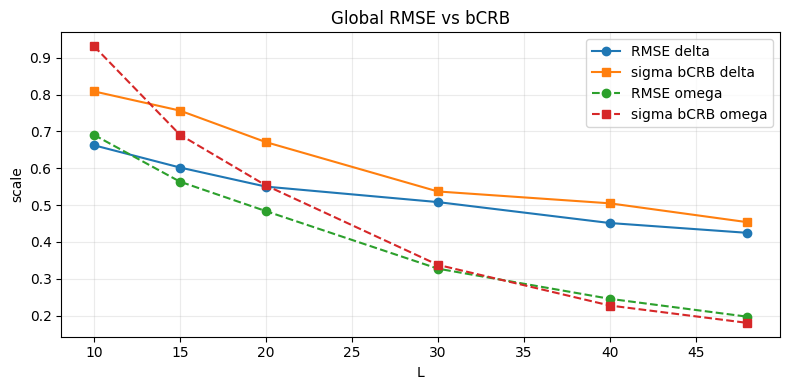

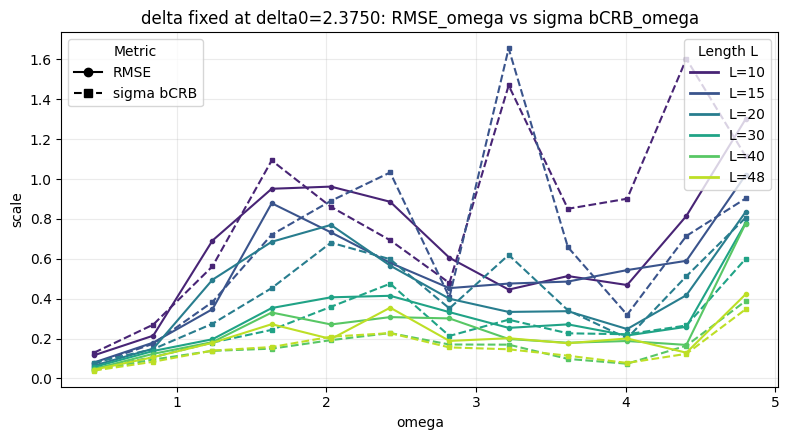

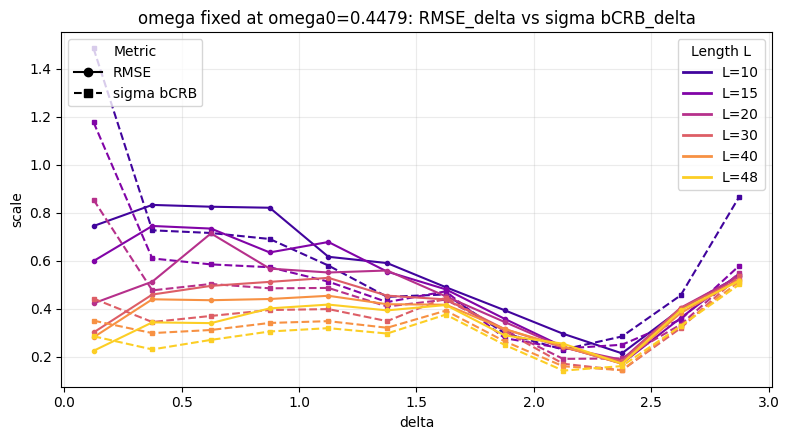

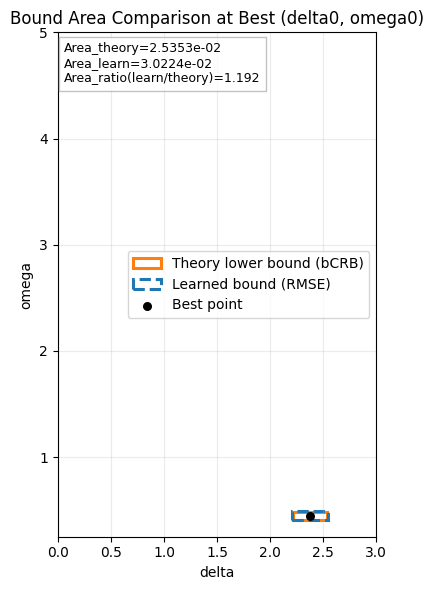

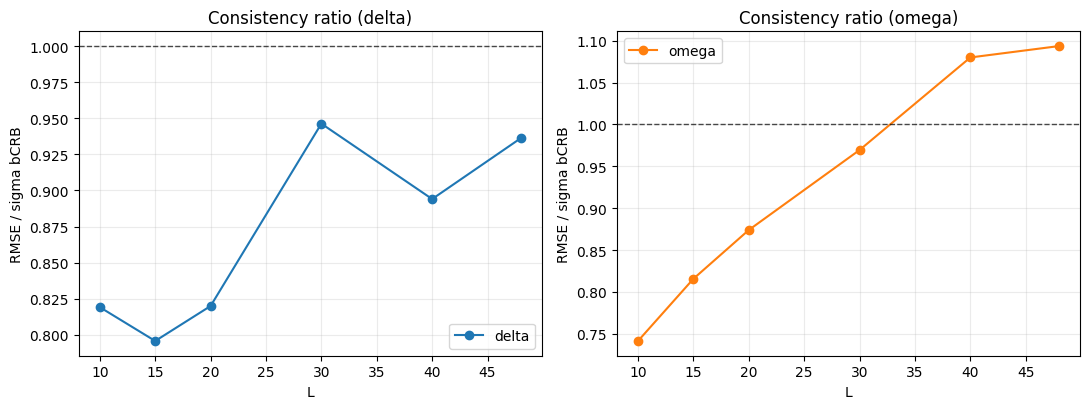

In [32]:
def summarize_binwise_rmse_bcrb(out, p1_grid, p2_grid, nbin_delta=12, nbin_omega=12, L=None):
    delta = np.asarray(out["delta_true"], dtype=np.float64)
    omega = np.asarray(out["omega_true"], dtype=np.float64)
    mse_d = np.asarray(out["mse_delta"], dtype=np.float64)
    mse_o = np.asarray(out["mse_omega"], dtype=np.float64)
    bcrb_d = np.asarray(out["crb_var_delta"], dtype=np.float64)
    bcrb_o = np.asarray(out["crb_var_omega"], dtype=np.float64)

    d_edges = np.linspace(float(np.min(p1_grid)), float(np.max(p1_grid)), nbin_delta + 1)
    o_edges = np.linspace(float(np.min(p2_grid)), float(np.max(p2_grid)), nbin_omega + 1)
    d_cent = 0.5 * (d_edges[:-1] + d_edges[1:])
    o_cent = 0.5 * (o_edges[:-1] + o_edges[1:])

    ib = np.digitize(delta, d_edges) - 1
    jb = np.digitize(omega, o_edges) - 1

    rows = []
    for i in range(nbin_delta):
        for j in range(nbin_omega):
            m = (ib == i) & (jb == j)
            if np.sum(m) == 0:
                continue

            md = m & np.isfinite(mse_d) & np.isfinite(bcrb_d) & (bcrb_d > 0)
            mo = m & np.isfinite(mse_o) & np.isfinite(bcrb_o) & (bcrb_o > 0)
            if np.sum(md) == 0 or np.sum(mo) == 0:
                continue

            rmse_d = float(np.sqrt(np.mean(mse_d[md])))
            rmse_o = float(np.sqrt(np.mean(mse_o[mo])))
            sig_b_d = float(np.sqrt(np.median(bcrb_d[md])))
            sig_b_o = float(np.sqrt(np.median(bcrb_o[mo])))

            rows.append({
                "L": None if L is None else as_int(L),
                "bin_i_delta": int(i),
                "bin_j_omega": int(j),
                "delta_center": float(d_cent[i]),
                "omega_center": float(o_cent[j]),
                "count": int(np.sum(m)),
                "n_delta": int(np.sum(md)),
                "n_omega": int(np.sum(mo)),
                "rmse_delta": rmse_d,
                "sigma_bcrb_delta": sig_b_d,
                "rmse_omega": rmse_o,
                "sigma_bcrb_omega": sig_b_o,
            })

    return pd.DataFrame(rows)


from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle


def select_default_point(binwise_report, L_ref=40, min_count=15):
    df = binwise_report[binwise_report["L"] == as_int(L_ref)].copy()
    if df.empty:
        raise ValueError(f"No binwise data available for L={L_ref}")

    cand = df[df["count"] >= as_int(min_count)].copy()
    if cand.empty:
        cand = df.copy()

    s_d = max(as_float(np.median(cand["rmse_delta"]), default=1e-12), 1e-12)
    s_o = max(as_float(np.median(cand["rmse_omega"]), default=1e-12), 1e-12)

    cand["precision_score"] = cand["rmse_delta"] / s_d + cand["rmse_omega"] / s_o
    cand = cand.sort_values(["precision_score", "count"], ascending=[True, False]).reset_index(drop=True)
    best = cand.iloc[0]
    return best


def plot_slice_delta_fixed(binwise_report, L_list, bin_i_delta, delta0):
    colors = plt.get_cmap("viridis")(np.linspace(0.1, 0.9, len(L_list)))
    fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

    for color, L in zip(colors, L_list):
        s = binwise_report[
            (binwise_report["L"] == as_int(L)) &
            (binwise_report["bin_i_delta"] == as_int(bin_i_delta))
        ].sort_values("omega_center")
        if len(s) == 0:
            continue
        ax.plot(s["omega_center"], s["rmse_omega"], color=color, linestyle='-', marker='o', markersize=3)
        ax.plot(s["omega_center"], s["sigma_bcrb_omega"], color=color, linestyle='--', marker='s', markersize=3)

    ax.set_xlabel("omega")
    ax.set_ylabel("scale")
    ax.set_title(f"delta fixed at delta0={delta0:.4f}: RMSE_omega vs sigma bCRB_omega")
    ax.grid(True, alpha=0.25)

    handles_l = [Line2D([0], [0], color=c, lw=2, label=f"L={L}") for c, L in zip(colors, L_list)]
    leg1 = ax.legend(handles=handles_l, title="Length L", loc="upper right")
    ax.add_artist(leg1)

    handles_m = [
        Line2D([0], [0], color='k', linestyle='-', marker='o', label='RMSE'),
        Line2D([0], [0], color='k', linestyle='--', marker='s', label='sigma bCRB'),
    ]
    ax.legend(handles=handles_m, title="Metric", loc="upper left")
    plt.tight_layout()


def plot_slice_omega_fixed(binwise_report, L_list, bin_j_omega, omega0):
    colors = plt.get_cmap("plasma")(np.linspace(0.1, 0.9, len(L_list)))
    fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))

    for color, L in zip(colors, L_list):
        s = binwise_report[
            (binwise_report["L"] == as_int(L)) &
            (binwise_report["bin_j_omega"] == as_int(bin_j_omega))
        ].sort_values("delta_center")
        if len(s) == 0:
            continue
        ax.plot(s["delta_center"], s["rmse_delta"], color=color, linestyle='-', marker='o', markersize=3)
        ax.plot(s["delta_center"], s["sigma_bcrb_delta"], color=color, linestyle='--', marker='s', markersize=3)

    ax.set_xlabel("delta")
    ax.set_ylabel("scale")
    ax.set_title(f"omega fixed at omega0={omega0:.4f}: RMSE_delta vs sigma bCRB_delta")
    ax.grid(True, alpha=0.25)

    handles_l = [Line2D([0], [0], color=c, lw=2, label=f"L={L}") for c, L in zip(colors, L_list)]
    leg1 = ax.legend(handles=handles_l, title="Length L", loc="upper right")
    ax.add_artist(leg1)

    handles_m = [
        Line2D([0], [0], color='k', linestyle='-', marker='o', label='RMSE'),
        Line2D([0], [0], color='k', linestyle='--', marker='s', label='sigma bCRB'),
    ]
    ax.legend(handles=handles_m, title="Metric", loc="upper left")
    plt.tight_layout()


def plot_bound_area_rectangles(delta0, omega0, sigma_d, sigma_o, rmse_d, rmse_o,
                               delta_min, delta_max, omega_min, omega_max, k_sigma=1.0):
    half_w_theory = float(k_sigma) * float(sigma_d)
    half_h_theory = float(k_sigma) * float(sigma_o)
    half_w_learn = float(k_sigma) * float(rmse_d)
    half_h_learn = float(k_sigma) * float(rmse_o)

    area_theory = (2.0 * half_w_theory) * (2.0 * half_h_theory)
    area_learn = (2.0 * half_w_learn) * (2.0 * half_h_learn)
    ratio_area = area_learn / max(area_theory, 1e-12)

    fig, ax = plt.subplots(1, 1, figsize=(6.5, 6.0))

    rect_theory = Rectangle(
        (delta0 - half_w_theory, omega0 - half_h_theory),
        2.0 * half_w_theory,
        2.0 * half_h_theory,
        fill=False,
        linewidth=2.2,
        edgecolor='tab:orange',
        label='Theory lower bound (bCRB)'
    )
    rect_learn = Rectangle(
        (delta0 - half_w_learn, omega0 - half_h_learn),
        2.0 * half_w_learn,
        2.0 * half_h_learn,
        fill=False,
        linewidth=2.2,
        linestyle='--',
        edgecolor='tab:blue',
        label='Learned bound (RMSE)'
    )

    ax.add_patch(rect_theory)
    ax.add_patch(rect_learn)
    ax.scatter([delta0], [omega0], c='k', s=30, zorder=5, label='Best point')

    ax.set_xlim(float(delta_min), float(delta_max))
    ax.set_ylim(float(omega_min), float(omega_max))
    ax.set_xlabel('delta')
    ax.set_ylabel('omega')
    ax.set_title('Bound Area Comparison at Best (delta0, omega0)')
    ax.grid(True, alpha=0.25)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')

    txt = (
        f"Area_theory={area_theory:.4e}\n"
        f"Area_learn={area_learn:.4e}\n"
        f"Area_ratio(learn/theory)={ratio_area:.3f}"
    )
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va='top', ha='left',
            fontsize=9, bbox=dict(facecolor='white', alpha=0.8, edgecolor='0.7'))
    plt.tight_layout()

    area_df = pd.DataFrame([{
        "delta0": float(delta0),
        "omega0": float(omega0),
        "k_sigma": float(k_sigma),
        "sigma_bcrb_delta": float(sigma_d),
        "sigma_bcrb_omega": float(sigma_o),
        "rmse_delta": float(rmse_d),
        "rmse_omega": float(rmse_o),
        "area_theory_bcrb": float(area_theory),
        "area_learn_rmse": float(area_learn),
        "area_ratio_learn_over_theory": float(ratio_area),
    }])
    return area_df


# Auto-load saved model when this cell is run standalone
if "modelRFF2D" not in globals() or modelRFF2D is None:
    model_path = DATAPATH / "models" / "2D" / "rff2d_latest.keras"
    weights_path = DATAPATH / "models" / "2D" / "rff2d_latest.weights.h5"

    if "load_rff2d_model_or_weights" in globals():
        modelRFF2D = load_rff2d_model_or_weights(model_path, weights_path)
    else:
        # Minimal fallback when training cell has not been run.
        try:
            modelRFF2D = keras.models.load_model(model_path, safe_mode=False, compile=False)
            print(f"Loaded model for CRB: {model_path}")
        except Exception:
            if not weights_path.exists():
                raise FileNotFoundError(
                    f"Failed to load .keras and weights not found: {weights_path}."
                )
            modelRFF2D = create_model_RFF2D(
                K1=K1, K2=K2,
                Kfeat=512,
                w_max=5,
                seed=0,
                use_log=True,
                add_logN=True,
                add_exp=True,
                Kexp=128,
                lam_min=lam_min_auto,
                lam_max=lam_max_auto,
                add_deepset=True,
                ds_width=128,
                ds_depth=3,
                droprate=0.0,
            )
            modelRFF2D.load_weights(weights_path)
            print(f"Loaded weights for CRB: {weights_path}")

expected_out_dim = as_int(len(p1_grid) * len(p2_grid))
out_dim = modelRFF2D.output_shape[-1]
if out_dim is None:
    raise RuntimeError("Loaded model has undefined output dimension.")
actual_out_dim = as_int(out_dim)
if actual_out_dim != expected_out_dim:
    raise ValueError(
        f"Model output dim {actual_out_dim} != grid dim {expected_out_dim}. "
        "Use a model trained with current K1/K2 grid settings."
    )

L_list = [10, 15, 20, 30, 40, 48]
binwise_all = []
summary_rows = []

for L in L_list:
    out = compute_per_sample_mse_and_crb_proxy(
        modelRFF2D, x_valid, y_valid,
        p1_grid, p2_grid, L,
        eps_d=3e-3, eps_o=3e-3,
        eig_floor=1e-8,
        max_samples=4000,
    )

    df_bin = summarize_binwise_rmse_bcrb(
        out, p1_grid, p2_grid,
        nbin_delta=12, nbin_omega=12,
        L=L,
    )
    binwise_all.append(df_bin)

    summary_rows.append({
        "L": as_int(L),
        "bins_used": int(len(df_bin)),
        "rmse_delta_bin_median": float(np.median(df_bin["rmse_delta"])),
        "sigma_bcrb_delta_bin_median": float(np.median(df_bin["sigma_bcrb_delta"])),
        "rmse_omega_bin_median": float(np.median(df_bin["rmse_omega"])),
        "sigma_bcrb_omega_bin_median": float(np.median(df_bin["sigma_bcrb_omega"])),
    })

binwise_report = pd.concat(binwise_all, ignore_index=True)
summary_binwise = pd.DataFrame(summary_rows).sort_values("L").reset_index(drop=True)

# Figure 1 (kept): global trend
global_trend = summary_binwise[[
    "L",
    "rmse_delta_bin_median",
    "sigma_bcrb_delta_bin_median",
    "rmse_omega_bin_median",
    "sigma_bcrb_omega_bin_median",
]]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(global_trend["L"], global_trend["rmse_delta_bin_median"], "o-", label="RMSE delta")
ax.plot(global_trend["L"], global_trend["sigma_bcrb_delta_bin_median"], "s-", label="sigma bCRB delta")
ax.plot(global_trend["L"], global_trend["rmse_omega_bin_median"], "o--", label="RMSE omega")
ax.plot(global_trend["L"], global_trend["sigma_bcrb_omega_bin_median"], "s--", label="sigma bCRB omega")
ax.set_xlabel("L")
ax.set_ylabel("scale")
ax.set_title("Global RMSE vs bCRB")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()

# Select the most precise default point from max L
best_bin = select_default_point(binwise_report, L_ref=max(L_list), min_count=15)
delta0 = as_float(best_bin["delta_center"])
omega0 = as_float(best_bin["omega_center"])
bin_i0 = as_int(best_bin["bin_i_delta"])
bin_j0 = as_int(best_bin["bin_j_omega"])

default_point = pd.DataFrame([{
    "L_ref": as_int(max(L_list)),
    "delta0": delta0,
    "omega0": omega0,
    "bin_i_delta": bin_i0,
    "bin_j_omega": bin_j0,
    "count": as_int(best_bin["count"]),
    "rmse_delta": as_float(best_bin["rmse_delta"]),
    "sigma_bcrb_delta": as_float(best_bin["sigma_bcrb_delta"]),
    "rmse_omega": as_float(best_bin["rmse_omega"]),
    "sigma_bcrb_omega": as_float(best_bin["sigma_bcrb_omega"]),
}])

# 2D slice plots requested
plot_slice_delta_fixed(binwise_report, L_list, bin_i_delta=bin_i0, delta0=delta0)
plot_slice_omega_fixed(binwise_report, L_list, bin_j_omega=bin_j0, omega0=omega0)

# New: rectangle area comparison at best point
area_compare = plot_bound_area_rectangles(
    delta0=delta0,
    omega0=omega0,
    sigma_d=as_float(best_bin["sigma_bcrb_delta"]),
    sigma_o=as_float(best_bin["sigma_bcrb_omega"]),
    rmse_d=as_float(best_bin["rmse_delta"]),
    rmse_o=as_float(best_bin["rmse_omega"]),
    delta_min=as_float(np.min(p1_grid)),
    delta_max=as_float(np.max(p1_grid)),
    omega_min=as_float(np.min(p2_grid)),
    omega_max=as_float(np.max(p2_grid)),
    k_sigma=1.0,
)

area_compare


### Barankin bound

#### 定义HCRB的计算与三个参考点的例子

In [40]:
from paramest_nn.quantum_tools import generate_clicks_TLS
from paramest_nn.quantum_tools import create_TLS_model
from paramest_nn.quantum_tools import compute_waiting_time


def simulate_mc_fixed_theta(delta0, omega0, L, n_mc, gamma=1.0, seed=0):
    # theta0 ∈ R^2, L: int, 返回长度为 n_mc 的 list，每个元素是 1D np.ndarray(事件时间)
    rng = np.random.default_rng(seed)
    model = create_TLS_model(delta0, omega0, as_int(gamma, default=1))
    taus_mc = []
    for _ in range(n_mc):
        np.random.seed(int(rng.integers(0, 2**31 - 1)))
        tau = model.simulateTrajectoryFixedJumps(njumpsMC=L)
        tau_arr = np.asarray(tau, dtype=np.float64)
        tau_arr = tau_arr[tau_arr > 0.0]
        if tau_arr.size == 0:
            raise ValueError("simulate_mc_fixed_theta: empty trajectory encountered")
        if tau_arr.size > L:
            tau_arr = tau_arr[:L]
        taus_mc.append(tau_arr)
    if not taus_mc:
        raise ValueError("simulate_mc_fixed_theta: no valid trajectories generated")
    return taus_mc


def loglik_tls(delta, omega, tau_list):
    # log f(tau_list; θ), θ = (delta, omega)
    tau_arr = np.asarray(tau_list, dtype=np.float64)
    if tau_arr.size == 0:
        raise ValueError("loglik_tls: tau_list must contain at least one event")
    w = np.array(
        [compute_waiting_time(t, omega, delta) for t in tau_arr],
        dtype=np.float64,
    )
    if np.any(w <= 0.0) or not np.all(np.isfinite(w)):
        raise ValueError(
            "loglik_tls: compute_waiting_time must return strictly positive, "
            "finite values for all events; otherwise TLS model violates "
            "Barankin / HCRB regularity assumptions"
        )
    return float(np.sum(np.log(w)))


def simulate_taus_tls(theta0, L, n_mc, gamma=1.0, seed=0):
    # theta0: array-like shape (2,), 返回长度为 n_mc 的 list，每个元素是 1D np.ndarray
    theta0 = np.asarray(theta0, dtype=np.float64)
    if theta0.shape != (2,):
        raise ValueError("simulate_taus_tls: theta0 must have shape (2,)")
    delta0, omega0 = float(theta0[0]), float(theta0[1])
    rng = np.random.default_rng(seed)
    taus = []
    for _ in range(n_mc):
        np.random.seed(int(rng.integers(0, 2**31 - 1)))
        tau = generate_clicks_TLS((delta0, omega0), njumpsMC=L, gamma=gamma)
        tau_arr = np.asarray(tau, dtype=np.float64)
        tau_arr = tau_arr[tau_arr > 0.0]
        if tau_arr.size == 0:
            raise ValueError("simulate_taus_tls: empty trajectory encountered")
        if tau_arr.size > L:
            tau_arr = tau_arr[:L]
        taus.append(tau_arr)
    if not taus:
        raise ValueError("simulate_taus_tls: no valid trajectories generated")
    return taus


def make_test_points(theta0, h_delta=0.05, h_omega=0.10, include_diagonal=True):
    # theta0: (2,), 返回 thetas_test ∈ R^{m×2}
    d0, o0 = float(theta0[0]), float(theta0[1])
    pts = [
        (d0 + h_delta, o0),
        (d0 - h_delta, o0),
        (d0, o0 + h_omega),
        (d0, o0 - h_omega),
    ]
    if include_diagonal:
        pts += [
            (d0 + h_delta, o0 + h_omega),
            (d0 + h_delta, o0 - h_omega),
            (d0 - h_delta, o0 + h_omega),
            (d0 - h_delta, o0 - h_omega),
        ]
    thetas_test = np.array(pts, dtype=np.float64)
    if thetas_test.ndim != 2 or thetas_test.shape[1] != 2:
        raise ValueError("make_test_points: generated test points must have shape (m, 2)")
    return thetas_test


def _is_finite_loglik_for_theta(theta, taus_check):
    d, o = float(theta[0]), float(theta[1])
    with np.errstate(invalid="ignore", divide="ignore", over="ignore", under="ignore"):
        ll = np.array([loglik_tls(d, o, tau) for tau in taus_check], dtype=np.float64)
    return bool(np.all(np.isfinite(ll)))


def make_test_points_feasible(
    theta0,
    taus_mc,
    h_delta,
    h_omega,
    include_diagonal=False,
    shrink_factor=0.5,
    max_shrink=5,
    min_h_delta=1e-4,
    min_h_omega=1e-4,
    max_check_samples=64,
):
    if len(taus_mc) == 0:
        return None, None, None, None

    n_chk = int(min(len(taus_mc), max_check_samples))
    taus_check = taus_mc[:n_chk]

    for k in range(int(max_shrink) + 1):
        scale = float(shrink_factor) ** int(k)
        hd = float(h_delta) * scale
        ho = float(h_omega) * scale
        if (hd < min_h_delta) or (ho < min_h_omega):
            continue

        thetas_test = make_test_points(
            theta0,
            h_delta=hd,
            h_omega=ho,
            include_diagonal=include_diagonal,
        )
        ok = True
        for th in thetas_test:
            if not _is_finite_loglik_for_theta(th, taus_check):
                ok = False
                break
        if ok:
            return thetas_test, hd, ho, int(k)

    return None, None, None, None


def hcrb_2d_stable(
    theta0,
    thetas_test,
    taus_mc,
    clip_dll=15.0,
    ridge=1e-10,
    rcond=1e-8,
    return_diag=True,
    center_z=False,
):
    r"""
    2D Hammersley?Chapman?Robbins / Barankin type bound.

    - ??: X = {?_i}, ? = (?, ?)^T.
    - ?????? ?_k, ??
      ?_k(X) = f(X; ?_k) / f(X; ?_0),
      Z_k(X) = ?_k(X) - 1 = exp(?(?_k;X) - ?(?_0;X)) - 1.
    - G ? R^{m?m}: G_{ij} = E_{?0}[ Z_i(X) Z_j(X) ].
    - H ? R^{2?m}: ? k ?? ?_k - ?_0.
    - ??: Cov(??) ? H G^+ H^T.
    """
    theta0 = np.asarray(theta0, dtype=np.float64)
    thetas_test = np.asarray(thetas_test, dtype=np.float64)
    if theta0.shape != (2,):
        raise ValueError("hcrb_2d_stable: theta0 must have shape (2,)")
    if thetas_test.ndim != 2 or thetas_test.shape[1] != 2:
        raise ValueError("hcrb_2d_stable: thetas_test must have shape (m, 2)")
    if not taus_mc:
        raise ValueError("hcrb_2d_stable: taus_mc must be a non-empty list of trajectories")

    M = len(taus_mc)
    m = thetas_test.shape[0]
    if M < m:
        raise ValueError("hcrb_2d_stable: need at least as many trajectories as test points")

    for tau in taus_mc:
        tau_arr = np.asarray(tau, dtype=np.float64)
        if tau_arr.size == 0:
            raise ValueError("hcrb_2d_stable: empty trajectory in taus_mc")
        if not np.all(np.isfinite(tau_arr)) or np.any(tau_arr <= 0.0):
            raise ValueError("hcrb_2d_stable: all tau must be positive and finite")

    with np.errstate(invalid="ignore", divide="ignore", over="ignore", under="ignore"):
        ll0 = np.array(
            [loglik_tls(theta0[0], theta0[1], tau) for tau in taus_mc],
            dtype=np.float64,
        )
    if not np.all(np.isfinite(ll0)):
        if return_diag:
            return None, None, np.full((m, m), np.nan), {
                "cond_G": np.inf,
                "cond_Gw": np.inf,
                "clip_frac": np.full(m, np.nan, dtype=np.float64),
                "clip_frac_max": np.nan,
                "rank": 0,
                "S": np.array([], dtype=np.float64),
                "center_z": bool(center_z),
                "m_test": int(m),
                "z_std_min": np.nan,
                "z_std_max": np.nan,
                "z_mean_abs_max": np.nan,
                "z_corr_offdiag_max": np.nan,
                "reason": "invalid_ll0",
            }
        return None, None, np.full((m, m), np.nan)

    Z = np.zeros((M, m), dtype=np.float64)
    clip_frac = np.zeros(m, dtype=np.float64)

    for k in range(m):
        dk, ok = thetas_test[k]
        with np.errstate(invalid="ignore", divide="ignore", over="ignore", under="ignore"):
            llk = np.array(
                [loglik_tls(dk, ok, tau) for tau in taus_mc],
                dtype=np.float64,
            )
        if not np.all(np.isfinite(llk)):
            if return_diag:
                return None, None, np.full((m, m), np.nan), {
                    "cond_G": np.inf,
                    "cond_Gw": np.inf,
                    "clip_frac": np.full(m, np.nan, dtype=np.float64),
                    "clip_frac_max": np.nan,
                    "rank": 0,
                    "S": np.array([], dtype=np.float64),
                    "center_z": bool(center_z),
                    "m_test": int(m),
                    "z_std_min": np.nan,
                    "z_std_max": np.nan,
                    "z_mean_abs_max": np.nan,
                    "z_corr_offdiag_max": np.nan,
                    "reason": "invalid_llk",
                }
            return None, None, np.full((m, m), np.nan)
        dll_raw = llk - ll0
        clip_frac[k] = float(np.mean((dll_raw > clip_dll) | (dll_raw < -clip_dll)))
        dll = np.clip(dll_raw, -clip_dll, clip_dll)
        Z[:, k] = np.expm1(dll)

    # Theory uses E[Z Z^T].
    # center_z=True keeps covariance-style approximation for ablation only.
    Z_used = (Z - Z.mean(axis=0, keepdims=True)) if center_z else Z

    # Diagnostics for pathology analysis
    z_std = np.std(Z, axis=0)
    z_mean = np.mean(Z, axis=0)
    z_std_min = float(np.min(z_std)) if z_std.size else np.nan
    z_std_max = float(np.max(z_std)) if z_std.size else np.nan
    z_mean_abs_max = float(np.max(np.abs(z_mean))) if z_mean.size else np.nan

    z_corr_offdiag_max = np.nan
    if m >= 2:
        try:
            C = np.corrcoef(Z, rowvar=False)
            mask = ~np.eye(m, dtype=bool)
            off = np.abs(C[mask])
            off = off[np.isfinite(off)]
            if off.size > 0:
                z_corr_offdiag_max = float(np.max(off))
        except Exception:
            pass

    G = (Z_used.T @ Z_used) / float(M)
    G = 0.5 * (G + G.T) + ridge * np.eye(m, dtype=np.float64)

    d = np.sqrt(np.diag(G))
    if np.any(d <= 0.0):
        if return_diag:
            return None, None, G, {
                "cond_G": np.inf,
                "cond_Gw": np.inf,
                "clip_frac": clip_frac,
                "clip_frac_max": float(np.max(clip_frac)),
                "rank": 0,
                "S": np.array([], dtype=np.float64),
                "center_z": bool(center_z),
                "m_test": int(m),
                "z_std_min": z_std_min,
                "z_std_max": z_std_max,
                "z_mean_abs_max": z_mean_abs_max,
                "z_corr_offdiag_max": z_corr_offdiag_max,
            }
        return None, None, G

    d = np.maximum(d, 1e-15)
    Dinv = np.diag(1.0 / d)
    Gw = Dinv @ G @ Dinv

    U, S, Vt = np.linalg.svd(Gw, full_matrices=False)
    if S.size == 0:
        if return_diag:
            return None, None, G, {
                "cond_G": np.inf,
                "cond_Gw": np.inf,
                "clip_frac": clip_frac,
                "clip_frac_max": float(np.max(clip_frac)),
                "rank": 0,
                "S": np.array([], dtype=np.float64),
                "center_z": bool(center_z),
                "m_test": int(m),
                "z_std_min": z_std_min,
                "z_std_max": z_std_max,
                "z_mean_abs_max": z_mean_abs_max,
                "z_corr_offdiag_max": z_corr_offdiag_max,
            }
        return None, None, G

    Smax = float(S[0])
    keep = S > (rcond * Smax)
    if not np.any(keep):
        if return_diag:
            return None, None, G, {
                "cond_G": np.inf,
                "cond_Gw": np.inf,
                "clip_frac": clip_frac,
                "clip_frac_max": float(np.max(clip_frac)),
                "rank": 0,
                "S": S,
                "center_z": bool(center_z),
                "m_test": int(m),
                "z_std_min": z_std_min,
                "z_std_max": z_std_max,
                "z_mean_abs_max": z_mean_abs_max,
                "z_corr_offdiag_max": z_corr_offdiag_max,
            }
        return None, None, G

    Sinv = np.zeros_like(S)
    Sinv[keep] = 1.0 / S[keep]
    Gw_pinv = (Vt.T * Sinv) @ U.T
    G_pinv = Dinv @ Gw_pinv @ Dinv

    H = (thetas_test - theta0[None, :]).T
    if H.shape != (2, m):
        raise RuntimeError("hcrb_2d_stable: H has unexpected shape")

    Cov_lower = H @ G_pinv @ H.T
    Cov_lower = 0.5 * (Cov_lower + Cov_lower.T)

    sigma_lower = np.sqrt(np.maximum(np.diag(Cov_lower), 0.0))

    if return_diag:
        return Cov_lower, sigma_lower, G, {
            "cond_G": float(np.linalg.cond(G)),
            "cond_Gw": float(np.linalg.cond(Gw)),
            "clip_frac": clip_frac,
            "clip_frac_max": float(np.max(clip_frac)),
            "rank": int(np.sum(keep)),
            "S": S,
            "center_z": bool(center_z),
            "m_test": int(m),
            "z_std_min": z_std_min,
            "z_std_max": z_std_max,
            "z_mean_abs_max": z_mean_abs_max,
            "z_corr_offdiag_max": z_corr_offdiag_max,
        }
    return Cov_lower, sigma_lower, G



def hcrb_best_over_steps_robust(
    theta0,
    L,
    n_mc=1000,
    gamma=1.0,
    seed=0,
    h_delta_list=(0.003, 0.005, 0.01, 0.02, 0.05),
    h_omega_list=(0.05, 0.10, 0.20),
    include_diagonal=False,
    clip_dll=10.0,
    ridge=1e-10,
    rcond=1e-8,
    cond_target=1e3,
    clip_frac_target=0.05,
    center_z=False,
    cond_hard_max=1e4,
    clip_frac_hard_max=0.20,
    corr_hard_max=0.995,
    z_std_min_hard=1e-8,
    require_full_rank=True,
):
    # 在不同 (h_delta, h_omega) 上搜索条件数好且 tight 的 HCRB
    taus_mc = simulate_mc_fixed_theta(
        theta0[0], theta0[1], L, n_mc, gamma=gamma, seed=seed
    )

    best = None
    stats = {"degenerate": 0, "nan": 0, "tested": 0}

    for hd in h_delta_list:
        for ho in h_omega_list:
            stats["tested"] += 1
            thetas_test, hd_eff, ho_eff, n_shrink = make_test_points_feasible(
                theta0=theta0,
                taus_mc=taus_mc,
                h_delta=hd,
                h_omega=ho,
                include_diagonal=include_diagonal,
                shrink_factor=0.5,
                max_shrink=5,
                min_h_delta=1e-4,
                min_h_omega=1e-4,
                max_check_samples=64,
            )
            if thetas_test is None:
                continue
            try:
                CovB, sigB, G, info = hcrb_2d_stable(
                    theta0,
                    thetas_test,
                    taus_mc,
                    clip_dll=clip_dll,
                    ridge=ridge,
                    rcond=rcond,
                    return_diag=True,
                    center_z=center_z,
                )
            except ValueError:
                stats["degenerate"] += 1
                continue

            if CovB is None or sigB is None:
                stats["degenerate"] += 1
                continue
            if (not np.all(np.isfinite(CovB))) or (not np.all(np.isfinite(sigB))):
                stats["nan"] += 1
                continue

            m_test = int(thetas_test.shape[0])
            cond_g = float(info["cond_G"])
            cond_gw = float(info["cond_Gw"])
            rank_g = int(info["rank"])
            clip_max = float(np.max(info["clip_frac"]))
            corr_max = as_float(info.get("z_corr_offdiag_max", np.nan), default=np.nan)
            z_std_min = as_float(info.get("z_std_min", np.nan), default=np.nan)
            if (not np.isfinite(cond_gw)) or (cond_gw > cond_hard_max):
                continue
            if require_full_rank and (rank_g < m_test):
                continue
            if np.isfinite(clip_max) and (clip_max > clip_frac_hard_max):
                continue
            if np.isfinite(corr_max) and (corr_max > corr_hard_max):
                continue
            if np.isfinite(z_std_min) and (z_std_min < z_std_min_hard):
                continue

            tight = float(np.trace(CovB))
            cond_pen = max(
                0.0,
                np.log10(cond_gw) - np.log10(cond_target),
            )
            clip_pen = max(
                0.0,
                (np.max(info["clip_frac"]) - clip_frac_target) / clip_frac_target,
            )
            score = tight * (1.0 + 5.0 * cond_pen + 5.0 * clip_pen)

            cand = {
                "h_delta": float(hd_eff),
                "h_omega": float(ho_eff),
                "h_delta_req": float(hd),
                "h_omega_req": float(ho),
                "n_shrink": int(n_shrink),
                "Cov": CovB,
                "sigma": sigB,
                "score": score,
                "tight": tight,
                "cond_G": float(cond_g),
                "cond_Gw": float(cond_gw),
                "clip_frac_max": float(clip_max),
                "z_corr_offdiag_max": float(corr_max),
                "z_std_min": float(z_std_min),
                "rank": int(rank_g),
                "stats": stats,
                "clip_dll": float(clip_dll),
                "include_diagonal": bool(include_diagonal),
            }
            if (best is None) or (score < best["score"]):
                best = cand
    return best


def hcrb_best_over_steps_with_taus(
    theta0,
    taus_mc,
    h_delta_list=(0.003, 0.005, 0.01, 0.02, 0.05),
    h_omega_list=(0.05, 0.10, 0.20),
    include_diagonal=False,
    clip_dll=10.0,
    ridge=1e-10,
    rcond=1e-8,
    cond_target=1e3,
    clip_frac_target=0.05,
    center_z=False,
    cond_hard_max=1e4,
    clip_frac_hard_max=0.20,
    corr_hard_max=0.995,
    z_std_min_hard=1e-8,
    require_full_rank=True,
):
    # 已有固定样本 {τ} 时，在 step 大小网格上选最稳定的 HCRB
    best = None
    for hd in h_delta_list:
        for ho in h_omega_list:
            thetas_test, hd_eff, ho_eff, n_shrink = make_test_points_feasible(
                theta0=theta0,
                taus_mc=taus_mc,
                h_delta=hd,
                h_omega=ho,
                include_diagonal=include_diagonal,
                shrink_factor=0.5,
                max_shrink=5,
                min_h_delta=1e-4,
                min_h_omega=1e-4,
                max_check_samples=64,
            )
            if thetas_test is None:
                continue
            try:
                CovB, sigB, G, info = hcrb_2d_stable(
                    theta0,
                    thetas_test,
                    taus_mc,
                    clip_dll=clip_dll,
                    ridge=ridge,
                    rcond=rcond,
                    return_diag=True,
                    center_z=center_z,
                )
            except ValueError:
                continue
            if CovB is None or sigB is None:
                continue
            if (not np.all(np.isfinite(CovB))) or (not np.all(np.isfinite(sigB))):
                continue

            m_test = int(thetas_test.shape[0])
            cond_g = float(info["cond_G"])
            cond_gw = float(info["cond_Gw"])
            rank_g = int(info["rank"])
            clip_max = float(np.max(info["clip_frac"]))
            corr_max = as_float(info.get("z_corr_offdiag_max", np.nan), default=np.nan)
            z_std_min = as_float(info.get("z_std_min", np.nan), default=np.nan)
            if (not np.isfinite(cond_gw)) or (cond_gw > cond_hard_max):
                continue
            if require_full_rank and (rank_g < m_test):
                continue
            if np.isfinite(clip_max) and (clip_max > clip_frac_hard_max):
                continue
            if np.isfinite(corr_max) and (corr_max > corr_hard_max):
                continue
            if np.isfinite(z_std_min) and (z_std_min < z_std_min_hard):
                continue

            tight = float(np.trace(CovB))
            cond_pen = max(
                0.0,
                np.log10(cond_gw) - np.log10(cond_target),
            )
            clip_pen = max(
                0.0,
                (np.max(info["clip_frac"]) - clip_frac_target) / clip_frac_target,
            )
            score = tight * (1.0 + 5.0 * cond_pen + 5.0 * clip_pen)

            cand = {
                "h_delta": float(hd_eff),
                "h_omega": float(ho_eff),
                "h_delta_req": float(hd),
                "h_omega_req": float(ho),
                "n_shrink": int(n_shrink),
                "Cov": CovB,
                "sigma": sigB,
                "score": score,
                "tight": tight,
                "cond_G": float(cond_g),
                "cond_Gw": float(cond_gw),
                "clip_frac_max": float(clip_max),
                "z_corr_offdiag_max": float(corr_max),
                "z_std_min": float(z_std_min),
                "rank": int(rank_g),
            }
            if (best is None) or (score < best["score"]):
                best = cand
    return best

def diagnose_hcrb_pathology(
    theta0,
    L,
    n_mc=1000,
    gamma=1.0,
    seed=0,
    h_delta_list=(0.003, 0.005, 0.01, 0.02, 0.05),
    h_omega_list=(0.05, 0.10, 0.20),
    include_diagonal=False,
    clip_dll=10.0,
    ridge=1e-10,
    rcond=1e-8,
    cond_hard_max=1e4,
    center_z=False,
):
    taus_mc = simulate_mc_fixed_theta(theta0[0], theta0[1], as_int(L), as_int(n_mc), gamma=gamma, seed=seed)

    rows = []
    for hd in h_delta_list:
        for ho in h_omega_list:
            thetas_test, hd_eff, ho_eff, n_shrink = make_test_points_feasible(
                theta0=theta0,
                taus_mc=taus_mc,
                h_delta=hd,
                h_omega=ho,
                include_diagonal=include_diagonal,
                shrink_factor=0.5,
                max_shrink=5,
                min_h_delta=1e-4,
                min_h_omega=1e-4,
                max_check_samples=64,
            )
            if thetas_test is None:
                rows.append({
                    "h_delta": float(hd),
                    "h_omega": float(ho),
                    "status": "failed",
                    "reason": "infeasible_test_points",
                })
                continue
            try:
                CovB, sigB, G, info = hcrb_2d_stable(
                    theta0=theta0,
                    thetas_test=thetas_test,
                    taus_mc=taus_mc,
                    clip_dll=clip_dll,
                    ridge=ridge,
                    rcond=rcond,
                    return_diag=True,
                    center_z=center_z,
                )
            except Exception as e:
                rows.append({
                    "h_delta": float(hd),
                    "h_omega": float(ho),
                    "status": "exception",
                    "reason": str(type(e).__name__),
                })
                continue

            cond_g = as_float(info.get("cond_G", np.inf), default=np.inf)
            cond_gw = as_float(info.get("cond_Gw", np.inf), default=np.inf)
            rank_g = as_int(info.get("rank", 0), default=0)
            m_test = as_int(info.get("m_test", thetas_test.shape[0]), default=thetas_test.shape[0])
            clip_max = as_float(info.get("clip_frac_max", np.nan), default=np.nan)

            reason = "ok"
            if CovB is None:
                reason = "degenerate"
            elif (not np.isfinite(cond_gw)) or (cond_gw > cond_hard_max):
                reason = "ill_cond"
            elif rank_g < m_test:
                reason = "rank_deficient"
            elif np.isfinite(clip_max) and clip_max > 0.2:
                reason = "heavy_clip"
            elif np.isfinite(as_float(info.get("z_std_min", np.nan), default=np.nan)) and as_float(info.get("z_std_min", np.nan), default=np.nan) < 1e-8:
                reason = "low_variance_Z"
            elif np.isfinite(as_float(info.get("z_corr_offdiag_max", np.nan), default=np.nan)) and as_float(info.get("z_corr_offdiag_max", np.nan), default=np.nan) > 0.995:
                reason = "collinear_Z"

            rows.append({
                "h_delta": float(hd_eff),
                "h_omega": float(ho_eff),
                "h_delta_req": float(hd),
                "h_omega_req": float(ho),
                "n_shrink": int(n_shrink),
                "status": "ok" if CovB is not None else "failed",
                "reason": reason,
                "cond_G": cond_g,
                "cond_Gw": cond_gw,
                "rank": rank_g,
                "m_test": m_test,
                "clip_frac_max": clip_max,
                "z_std_min": as_float(info.get("z_std_min", np.nan), default=np.nan),
                "z_std_max": as_float(info.get("z_std_max", np.nan), default=np.nan),
                "z_mean_abs_max": as_float(info.get("z_mean_abs_max", np.nan), default=np.nan),
                "z_corr_offdiag_max": as_float(info.get("z_corr_offdiag_max", np.nan), default=np.nan),
                "trace_cov": float(np.trace(CovB)) if CovB is not None else np.nan,
            })

    df = pd.DataFrame(rows)
    if len(df) > 0:
        df = df.sort_values(["reason", "cond_Gw", "trace_cov"], na_position="last").reset_index(drop=True)
    return df


# ===== Barankin spot-check on representative points =====

def pick_representative_points_from_binwise(binwise_report, L_ref=40, min_count=20):
    if binwise_report is None or len(binwise_report) == 0:
        raise ValueError("binwise_report is empty. Run the binwise analysis cell first.")

    df = binwise_report[binwise_report["L"] == as_int(L_ref)].copy()
    if df.empty:
        raise ValueError(f"No binwise rows found for L_ref={L_ref}")

    cand = df[df["count"] >= as_int(min_count)].copy()
    if cand.empty:
        cand = df.copy()

    s_d = max(as_float(np.median(cand["rmse_delta"]), default=1e-12), 1e-12)
    s_o = max(as_float(np.median(cand["rmse_omega"]), default=1e-12), 1e-12)
    cand["precision_score"] = cand["rmse_delta"] / s_d + cand["rmse_omega"] / s_o
    cand = cand.sort_values(["precision_score", "count"], ascending=[True, False]).reset_index(drop=True)

    best = cand.iloc[0]
    mid = cand.iloc[len(cand) // 2]
    hard = cand.iloc[-1]

    pts = pd.DataFrame([
        {
            "tag": "best",
            "delta0": as_float(best["delta_center"]),
            "omega0": as_float(best["omega_center"]),
            "count": as_int(best["count"]),
            "score": as_float(best["precision_score"]),
        },
        {
            "tag": "mid",
            "delta0": as_float(mid["delta_center"]),
            "omega0": as_float(mid["omega_center"]),
            "count": as_int(mid["count"]),
            "score": as_float(mid["precision_score"]),
        },
        {
            "tag": "hard",
            "delta0": as_float(hard["delta_center"]),
            "omega0": as_float(hard["omega_center"]),
            "count": as_int(hard["count"]),
            "score": as_float(hard["precision_score"]),
        },
    ])
    return pts


def evaluate_model_mse_at_theta_from_taus(model, taus_mc, theta0, L, p1_grid, p2_grid):
    n = len(taus_mc)
    x = np.zeros((n, as_int(L)), dtype=np.float32)
    for i, tau in enumerate(taus_mc):
        t = np.asarray(tau, dtype=np.float64)
        t = t[t > 0.0]
        if t.size > L:
            t = t[:L]
        x[i, :t.size] = t.astype(np.float32)

    logits = model.predict(x[:, :L], verbose=0)
    delta_hat, omega_hat = posterior_mean_from_logits(logits, p1_grid, p2_grid)

    d0 = float(theta0[0])
    o0 = float(theta0[1])

    mean_delta_hat = float(np.mean(delta_hat))
    mean_omega_hat = float(np.mean(omega_hat))
    bias_delta = float(mean_delta_hat - d0)
    bias_omega = float(mean_omega_hat - o0)
    err = np.stack([delta_hat - d0, omega_hat - o0], axis=1).astype(np.float64)
    mse_matrix = (err.T @ err) / float(max(err.shape[0], 1))
    err_centered = err - np.mean(err, axis=0, keepdims=True)
    cov_err = (err_centered.T @ err_centered) / float(max(err.shape[0], 1))
    var_delta = float(np.var(delta_hat, ddof=0))
    var_omega = float(np.var(omega_hat, ddof=0))
    mse_delta = float(np.mean((delta_hat - d0) ** 2))
    mse_omega = float(np.mean((omega_hat - o0) ** 2))
    return {
        "mean_delta_hat": mean_delta_hat,
        "mean_omega_hat": mean_omega_hat,
        "bias_delta": bias_delta,
        "bias_omega": bias_omega,
        "mse_matrix": mse_matrix,
        "cov_err": cov_err,
        "n_samples": int(err.shape[0]),
        "var_delta": var_delta,
        "var_omega": var_omega,
        "mse_delta": mse_delta,
        "mse_omega": mse_omega,
        "rmse_delta": float(np.sqrt(mse_delta)),
        "rmse_omega": float(np.sqrt(mse_omega)),
    }


def _split_taus_in_half(taus_mc, seed):
    n = len(taus_mc)
    if n < 8:
        return None, None
    rng = np.random.default_rng(int(seed))
    perm = rng.permutation(n)
    h = n // 2
    idx_a = perm[:h]
    idx_b = perm[h:]
    if (len(idx_a) < 4) or (len(idx_b) < 4):
        return None, None
    taus_a = [taus_mc[int(i)] for i in idx_a]
    taus_b = [taus_mc[int(i)] for i in idx_b]
    return taus_a, taus_b


def _evaluate_barankin_single_split(
    model,
    theta0,
    taus_select,
    taus_eval,
    L,
    p1_grid,
    p2_grid,
    center_z=False,
    matrix_tol=1e-6,
):
    hb = hcrb_best_over_steps_with_taus(
        theta0,
        taus_select,
        h_delta_list=(0.003, 0.005, 0.01, 0.02, 0.05),
        h_omega_list=(0.05, 0.10, 0.20),
        include_diagonal=False,
        clip_dll=10.0,
        ridge=1e-10,
        rcond=1e-8,
        cond_target=1e3,
        clip_frac_target=0.05,
        center_z=center_z,
        cond_hard_max=1e4,
        clip_frac_hard_max=0.20,
        corr_hard_max=0.995,
        z_std_min_hard=1e-8,
        require_full_rank=True,
    )
    if hb is None:
        return None

    est = evaluate_model_mse_at_theta_from_taus(
        model=model,
        taus_mc=taus_eval,
        theta0=theta0,
        L=as_int(L),
        p1_grid=p1_grid,
        p2_grid=p2_grid,
    )

    bar_cov_unb = np.asarray(hb["Cov"], dtype=np.float64)
    b = np.array([est["bias_delta"], est["bias_omega"]], dtype=np.float64)
    bar_cov_bias = bar_cov_unb + np.outer(b, b)
    bar_cov_bias = 0.5 * (bar_cov_bias + bar_cov_bias.T)
    mse_mat = np.asarray(est["mse_matrix"], dtype=np.float64)
    mse_mat = 0.5 * (mse_mat + mse_mat.T)
    diff = 0.5 * ((mse_mat - bar_cov_bias) + (mse_mat - bar_cov_bias).T)
    try:
        eig_min = float(np.min(np.linalg.eigvalsh(diff)))
    except np.linalg.LinAlgError:
        eig_min = np.nan

    bar_var_delta_unb = float(max(bar_cov_unb[0, 0], 0.0))
    bar_var_omega_unb = float(max(bar_cov_unb[1, 1], 0.0))
    bar_var_delta_bias = float(max(bar_cov_bias[0, 0], 0.0))
    bar_var_omega_bias = float(max(bar_cov_bias[1, 1], 0.0))

    ratio_d_unb = float(est["mse_delta"] / max(bar_var_delta_unb, 1e-12))
    ratio_o_unb = float(est["mse_omega"] / max(bar_var_omega_unb, 1e-12))
    ratio_d = float(est["mse_delta"] / max(bar_var_delta_bias, 1e-12))
    ratio_o = float(est["mse_omega"] / max(bar_var_omega_bias, 1e-12))

    return {
        "rmse_delta": float(est["rmse_delta"]),
        "rmse_omega": float(est["rmse_omega"]),
        "bias_delta": float(est["bias_delta"]),
        "bias_omega": float(est["bias_omega"]),
        "var_delta": float(est["var_delta"]),
        "var_omega": float(est["var_omega"]),
        "mse_delta": float(est["mse_delta"]),
        "mse_omega": float(est["mse_omega"]),
        "mse_mat_trace": float(np.trace(mse_mat)),
        "barankin_mse_trace": float(np.trace(bar_cov_bias)),
        "barankin_var_delta_unb": bar_var_delta_unb,
        "barankin_var_omega_unb": bar_var_omega_unb,
        "barankin_var_delta": bar_var_delta_bias,
        "barankin_var_omega": bar_var_omega_bias,
        "ratio_delta_mse_over_barankin_unb": ratio_d_unb,
        "ratio_omega_mse_over_barankin_unb": ratio_o_unb,
        "ratio_delta_mse_over_barankin": ratio_d,
        "ratio_omega_mse_over_barankin": ratio_o,
        "pass_delta_unb": bool(est["mse_delta"] >= bar_var_delta_unb),
        "pass_omega_unb": bool(est["mse_omega"] >= bar_var_omega_unb),
        "pass_delta": bool(est["mse_delta"] >= bar_var_delta_bias),
        "pass_omega": bool(est["mse_omega"] >= bar_var_omega_bias),
        "pass_both": bool((est["mse_delta"] >= bar_var_delta_bias) and (est["mse_omega"] >= bar_var_omega_bias)),
        "pass_delta_relaxed": bool(ratio_d >= 0.8),
        "pass_omega_relaxed": bool(ratio_o >= 0.8),
        "pass_matrix": bool(np.isfinite(eig_min) and (eig_min >= -float(matrix_tol))),
        "matrix_eig_min": float(eig_min),
        "h_delta": float(hb["h_delta"]),
        "h_omega": float(hb["h_omega"]),
        "h_delta_req": as_float(hb.get("h_delta_req", hb["h_delta"]), default=as_float(hb["h_delta"])),
        "h_omega_req": as_float(hb.get("h_omega_req", hb["h_omega"]), default=as_float(hb["h_omega"])),
        "n_shrink": as_int(hb.get("n_shrink", 0), default=0),
        "cond_G": float(hb["cond_G"]),
        "cond_Gw": float(hb["cond_Gw"]),
        "rank": float(hb["rank"]),
        "n_eval": int(est["n_samples"]),
    }


def _cv_safe(v):
    arr = np.asarray(v, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size <= 1:
        return 0.0
    mu = float(np.mean(arr))
    if abs(mu) < 1e-12:
        return np.inf
    return float(np.std(arr, ddof=0) / abs(mu))


def run_barankin_spotcheck(
    model,
    p1_grid,
    p2_grid,
    binwise_report,
    L_eval=(10, 20, 40),
    n_mc=1000,
    gamma=1.0,
    seed=1234,
    L_ref_for_points=40,
    min_count=20,
    center_z=False,
    n_seeds=3,
    cv_hard_max=0.30,
    matrix_tol=1e-6,
):
    pts = pick_representative_points_from_binwise(
        binwise_report,
        L_ref=L_ref_for_points,
        min_count=min_count,
    )

    rows = []
    for pidx, prow in pts.iterrows():
        theta0 = np.array([float(prow["delta0"]), float(prow["omega0"])], dtype=np.float64)
        for L in L_eval:
            per_seed = []
            for sidx in range(int(n_seeds)):
                base_seed = as_int(seed + 100000 * as_int(pidx) + 1000 * as_int(L) + as_int(sidx))
                taus_mc = simulate_mc_fixed_theta(
                    theta0[0], theta0[1], as_int(L), as_int(n_mc), gamma=gamma, seed=base_seed
                )
                taus_a, taus_b = _split_taus_in_half(taus_mc, seed=base_seed + 17)
                if (taus_a is None) or (taus_b is None):
                    continue

                out_ab = _evaluate_barankin_single_split(
                    model=model,
                    theta0=theta0,
                    taus_select=taus_a,
                    taus_eval=taus_b,
                    L=as_int(L),
                    p1_grid=p1_grid,
                    p2_grid=p2_grid,
                    center_z=center_z,
                    matrix_tol=matrix_tol,
                )
                out_ba = _evaluate_barankin_single_split(
                    model=model,
                    theta0=theta0,
                    taus_select=taus_b,
                    taus_eval=taus_a,
                    L=as_int(L),
                    p1_grid=p1_grid,
                    p2_grid=p2_grid,
                    center_z=center_z,
                    matrix_tol=matrix_tol,
                )
                if (out_ab is None) or (out_ba is None):
                    continue

                keys_mean = [
                    "rmse_delta", "rmse_omega", "bias_delta", "bias_omega", "var_delta", "var_omega",
                    "mse_delta", "mse_omega", "mse_mat_trace", "barankin_mse_trace",
                    "barankin_var_delta_unb", "barankin_var_omega_unb",
                    "barankin_var_delta", "barankin_var_omega",
                    "ratio_delta_mse_over_barankin_unb", "ratio_omega_mse_over_barankin_unb",
                    "ratio_delta_mse_over_barankin", "ratio_omega_mse_over_barankin",
                    "matrix_eig_min", "h_delta", "h_omega", "h_delta_req", "h_omega_req",
                    "n_shrink", "cond_G", "cond_Gw", "rank", "n_eval",
                ]
                seed_row = {k: float(0.5 * (out_ab[k] + out_ba[k])) for k in keys_mean}
                seed_row["pass_delta_unb"] = bool(seed_row["ratio_delta_mse_over_barankin_unb"] >= 1.0)
                seed_row["pass_omega_unb"] = bool(seed_row["ratio_omega_mse_over_barankin_unb"] >= 1.0)
                seed_row["pass_delta"] = bool(seed_row["ratio_delta_mse_over_barankin"] >= 1.0)
                seed_row["pass_omega"] = bool(seed_row["ratio_omega_mse_over_barankin"] >= 1.0)
                seed_row["pass_both"] = bool(seed_row["pass_delta"] and seed_row["pass_omega"])
                seed_row["pass_delta_relaxed"] = bool(seed_row["ratio_delta_mse_over_barankin"] >= 0.8)
                seed_row["pass_omega_relaxed"] = bool(seed_row["ratio_omega_mse_over_barankin"] >= 0.8)
                seed_row["pass_matrix"] = bool((out_ab["pass_matrix"] and out_ba["pass_matrix"]))
                seed_row["matrix_eig_min"] = float(min(out_ab["matrix_eig_min"], out_ba["matrix_eig_min"]))
                per_seed.append(seed_row)

            if len(per_seed) == 0:
                rows.append({
                    "tag": str(prow["tag"]),
                    "delta0": float(theta0[0]),
                    "omega0": float(theta0[1]),
                    "L": as_int(L),
                    "n_mc": int(n_mc),
                    "status": "hcrb_failed",
                    "n_seed_success": 0,
                })
                continue

            sdf = pd.DataFrame(per_seed)
            agg = {k: float(sdf[k].mean()) for k in sdf.columns if sdf[k].dtype != bool}
            pass_matrix_rate = float(np.mean(sdf["pass_matrix"].astype(np.float64)))
            var_delta_cv = _cv_safe(sdf["barankin_var_delta"].values)
            var_omega_cv = _cv_safe(sdf["barankin_var_omega"].values)

            status = "ok"
            if (var_delta_cv > cv_hard_max) or (var_omega_cv > cv_hard_max) or (pass_matrix_rate < 2.0 / 3.0):
                status = "unstable"

            rows.append({
                "tag": str(prow["tag"]),
                "delta0": float(theta0[0]),
                "omega0": float(theta0[1]),
                "L": as_int(L),
                "n_mc": int(n_mc),
                "status": status,
                "n_seed_success": int(len(per_seed)),
                "rmse_delta": float(agg["rmse_delta"]),
                "rmse_omega": float(agg["rmse_omega"]),
                "barankin_sigma_delta_unb": float(np.sqrt(max(agg["barankin_var_delta_unb"], 0.0))),
                "barankin_sigma_omega_unb": float(np.sqrt(max(agg["barankin_var_omega_unb"], 0.0))),
                "barankin_sigma_delta": float(np.sqrt(max(agg["barankin_var_delta"], 0.0))),
                "barankin_sigma_omega": float(np.sqrt(max(agg["barankin_var_omega"], 0.0))),
                "bias_delta": float(agg["bias_delta"]),
                "bias_omega": float(agg["bias_omega"]),
                "var_delta": float(agg["var_delta"]),
                "var_omega": float(agg["var_omega"]),
                "mse_delta": float(agg["mse_delta"]),
                "mse_omega": float(agg["mse_omega"]),
                "mse_mat_trace": float(agg["mse_mat_trace"]),
                "barankin_mse_trace": float(agg["barankin_mse_trace"]),
                "barankin_var_delta_unb": float(agg["barankin_var_delta_unb"]),
                "barankin_var_omega_unb": float(agg["barankin_var_omega_unb"]),
                "barankin_var_delta": float(agg["barankin_var_delta"]),
                "barankin_var_omega": float(agg["barankin_var_omega"]),
                "ratio_delta_mse_over_barankin_unb": float(agg["ratio_delta_mse_over_barankin_unb"]),
                "ratio_omega_mse_over_barankin_unb": float(agg["ratio_omega_mse_over_barankin_unb"]),
                "ratio_delta_mse_over_barankin": float(agg["ratio_delta_mse_over_barankin"]),
                "ratio_omega_mse_over_barankin": float(agg["ratio_omega_mse_over_barankin"]),
                "pass_delta_unb": bool(agg["ratio_delta_mse_over_barankin_unb"] >= 1.0),
                "pass_omega_unb": bool(agg["ratio_omega_mse_over_barankin_unb"] >= 1.0),
                "pass_delta": bool(agg["ratio_delta_mse_over_barankin"] >= 1.0),
                "pass_omega": bool(agg["ratio_omega_mse_over_barankin"] >= 1.0),
                "pass_both": bool((agg["ratio_delta_mse_over_barankin"] >= 1.0) and (agg["ratio_omega_mse_over_barankin"] >= 1.0)),
                "pass_delta_relaxed": bool(agg["ratio_delta_mse_over_barankin"] >= 0.8),
                "pass_omega_relaxed": bool(agg["ratio_omega_mse_over_barankin"] >= 0.8),
                "pass_matrix": bool(pass_matrix_rate >= 2.0 / 3.0),
                "pass_matrix_rate": float(pass_matrix_rate),
                "matrix_eig_min": float(agg["matrix_eig_min"]),
                "barankin_var_delta_cv": float(var_delta_cv),
                "barankin_var_omega_cv": float(var_omega_cv),
                "h_delta": float(agg["h_delta"]),
                "h_omega": float(agg["h_omega"]),
                "h_delta_req": float(agg["h_delta_req"]),
                "h_omega_req": float(agg["h_omega_req"]),
                "n_shrink": float(agg["n_shrink"]),
                "cond_G": float(agg["cond_G"]),
                "cond_Gw": float(agg["cond_Gw"]),
                "rank": float(agg["rank"]),
                "center_z": bool(center_z),
            })

    df = pd.DataFrame(rows)
    if len(df) == 0:
        return pts, df, pd.DataFrame()

    df = df.sort_values(["tag", "L"]).reset_index(drop=True)
    ok = df[df["status"] == "ok"].copy()
    if len(ok) > 0:
        summary = (
            ok.groupby("L", as_index=False)
            .agg(
                ratio_delta_median=("ratio_delta_mse_over_barankin", "median"),
                ratio_omega_median=("ratio_omega_mse_over_barankin", "median"),
                pass_both_rate=("pass_both", "mean"),
                pass_matrix_rate=("pass_matrix", "mean"),
                n_points=("pass_both", "size"),
            )
            .sort_values("L")
            .reset_index(drop=True)
        )
    else:
        summary = pd.DataFrame()

    return pts, df, summary


barankin_points, barankin_spotcheck, barankin_summary = run_barankin_spotcheck(
    model=modelRFF2D,
    p1_grid=p1_grid,
    p2_grid=p2_grid,
    binwise_report=binwise_report,
    L_eval=(10, 20, 40),
    n_mc=1000,
    gamma=1.0,
    seed=1234,
    L_ref_for_points=40,
    min_count=20,
    center_z=False,
    n_seeds=3,
    cv_hard_max=0.30,
    matrix_tol=1e-6,
)

barankin_points, barankin_spotcheck, barankin_summary


(    tag  delta0    omega0  count     score
 0  best   2.125  0.447917     26  0.804709
 1   mid   0.625  2.427083     31  2.205604
 2  hard   0.125  4.802083     31  5.608592,
     tag  delta0    omega0   L  n_mc       status  rmse_delta  rmse_omega  \
 0  best   2.125  0.447917  10   300           ok    0.261289    0.116725   
 1  best   2.125  0.447917  20   300           ok    0.206999    0.062986   
 2  best   2.125  0.447917  40   300           ok    0.179624    0.048028   
 3  hard   0.125  4.802083  10   300  hcrb_failed         NaN         NaN   
 4  hard   0.125  4.802083  20   300  hcrb_failed         NaN         NaN   
 5  hard   0.125  4.802083  40   300  hcrb_failed         NaN         NaN   
 6   mid   0.625  2.427083  10   300           ok    0.958882    0.638773   
 7   mid   0.625  2.427083  20   300           ok    0.734105    0.508284   
 8   mid   0.625  2.427083  40   300           ok    0.531092    0.408508   
 
    barankin_sigma_delta_unb  barankin_sigma_omega_

#### 病态诊断

In [41]:
diag_best = diagnose_hcrb_pathology(
    theta0=np.array([2.125, 0.447917], dtype=np.float64),
    L=40,
    n_mc=1000,
    include_diagonal=False,
    center_z=False,
)
diag_best


,h_delta,h_omega,status,reason,cond_G,cond_Gw,rank,m_test,clip_frac_max,z_std_min,z_std_max,z_mean_abs_max,z_corr_offdiag_max,trace_cov
0,0.05,0.20,ok,heavy_clip,7.914265e+08,112.283944,4,4,1.000000,0.398965,6607.939725,2201.646620,0.971978,0.036504
1,0.02,0.20,ok,heavy_clip,3.872310e+10,363.582472,4,4,1.000000,0.211765,6607.939725,2201.646620,0.969395,0.041406
2,0.01,0.20,ok,heavy_clip,7.053624e+11,1117.657050,4,4,1.000000,0.122611,6607.939725,2201.646620,0.988293,0.042358
3,0.05,0.10,ok,ok,9.715968e+08,113.719377,4,4,0.100000,0.398965,6607.924698,2201.691701,0.971979,0.042599
4,0.05,0.05,ok,ok,1.091569e+09,134.674977,4,4,0.093333,0.398965,5406.405786,1690.744758,0.968869,0.061099
5,0.02,0.05,ok,ok,3.211481e+10,342.713835,4,4,0.093333,0.211765,5406.405786,1690.744758,0.954515,0.063045
6,0.02,0.10,ok,ok,4.084756e+10,371.303288,4,4,0.100000,0.211765,6607.924698,2201.691701,0.969396,0.047200
7,0.01,0.05,ok,ok,5.049202e+11,1135.678631,4,4,0.093333,0.122611,5406.405786,1690.744758,0.988293,0.063312
8,0.01,0.10,ok,ok,7.348943e+11,1158.889279,4,4,0.100000,0.122611,6607.924698,2201.691701,0.988293,0.048038
